In [ ]:
#cluster_v3
from __future__ import annotations

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import rasterio
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler


# =============================================================================
# USER SETTINGS
# =============================================================================

out_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)
out_dir = Path(r"C:\NCA_DATA\cluster_v3")
out_dir.mkdir(parents=True, exist_ok=True)

sample_n = 1_000_000
random_seed = 42

RAW_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

k_values = list(range(20, 31))

batch_size = 8192
n_init = 20
max_iter = 1000

silhouette_repeats = 5
silhouette_n = 40_000

per_cluster_target = 5_000


# =============================================================================
# EXPLICIT BAND MAP
# =============================================================================

FEATURE_MAP = {
    "B2":  {"BETA0": 1,  "AMP1": 2,  "AMP2": 4,  "AMP3": 6,  "AMP4": 8},
    "B3":  {"BETA0": 11, "AMP1": 12, "AMP2": 14, "AMP3": 16, "AMP4": 18},
    "B4":  {"BETA0": 21, "AMP1": 22, "AMP2": 24, "AMP3": 26, "AMP4": 28},
    "B5":  {"BETA0": 31, "AMP1": 32, "AMP2": 34, "AMP3": 36, "AMP4": 38},
    "B6":  {"BETA0": 41, "AMP1": 42, "AMP2": 44, "AMP3": 46, "AMP4": 48},
    "B7":  {"BETA0": 51, "AMP1": 52, "AMP2": 54, "AMP3": 56, "AMP4": 58},
    "B8":  {"BETA0": 61, "AMP1": 62, "AMP2": 64, "AMP3": 66, "AMP4": 68},
    "B8A": {"BETA0": 71, "AMP1": 72, "AMP2": 74, "AMP3": 76, "AMP4": 78},
    "B11": {"BETA0": 81, "AMP1": 82, "AMP2": 84, "AMP3": 86, "AMP4": 88},
    "B12": {"BETA0": 91, "AMP1": 92, "AMP2": 94, "AMP3": 96, "AMP4": 98},
}


# =============================================================================
# HELPERS
# =============================================================================

def clip_to_p99(X: np.ndarray, name: str, out_dir: Path) -> np.ndarray:
    print(f"\nComputing p99 clipping for {name}...")
    p99 = np.percentile(X, 99, axis=0)
    np.save(out_dir / f"{name}_p99_thresholds.npy", p99)

    print(f"{name}: p99 range = [{p99.min():.4f}, {p99.max():.4f}]")

    n_clipped = np.sum(X > p99)
    print(f"{name}: values clipped = {n_clipped:,}")

    return np.minimum(X, p99).astype(np.float32)


def validate_feature_map(feature_map):
    needed = ["BETA0", "AMP1", "AMP2", "AMP3", "AMP4"]
    for band in RAW_BANDS:
        for k in needed:
            if k not in feature_map[band]:
                raise RuntimeError(f"Missing {k} for {band}")


def get_selected_band_indices(feature_map):
    selected = []
    for band in RAW_BANDS:
        selected.extend([
            feature_map[band]["BETA0"],
            feature_map[band]["AMP1"],
            feature_map[band]["AMP2"],
            feature_map[band]["AMP3"],
            feature_map[band]["AMP4"],
        ])
    return sorted(set(selected))


def build_selected_band_lookup(feature_map, selected_indices):
    pos_map = {idx: pos for pos, idx in enumerate(selected_indices)}
    return {
        band: {comp: pos_map[idx] for comp, idx in feature_map[band].items()}
        for band in RAW_BANDS
    }


def get_valid_mask(arr, src):
    valid = (~np.any(arr.mask, axis=0)) & np.all(np.isfinite(arr.data), axis=0)
    nodata = src.nodata
    if nodata is not None:
        valid &= ~np.any(arr.data == nodata, axis=0)
    return valid


def extract_features_from_block(block, lookup):
    energy_cols = []
    full_cols = []

    for band in RAW_BANDS:
        beta0 = block[lookup[band]["BETA0"]].reshape(-1)
        a1 = block[lookup[band]["AMP1"]].reshape(-1)
        a2 = block[lookup[band]["AMP2"]].reshape(-1)
        a3 = block[lookup[band]["AMP3"]].reshape(-1)
        a4 = block[lookup[band]["AMP4"]].reshape(-1)

        energy = np.sqrt(a1**2 + a2**2 + a3**2 + a4**2)

        energy_cols.extend([beta0, energy])
        full_cols.extend([beta0, a1, a2, a3, a4])

    return (
        np.column_stack(energy_cols).astype(np.float32),
        np.column_stack(full_cols).astype(np.float32),
    )


def compute_repeated_silhouette(Xz, labels, n_subsample, n_repeats, seed):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_repeats):
        idx = rng.choice(Xz.shape[0], size=n_subsample, replace=False)
        vals.append(silhouette_score(Xz[idx], labels[idx]))
    return float(np.mean(vals)), float(np.std(vals)), vals


def run_k_diagnostics(X, name, k_values, out_dir, random_seed=42):
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)
    joblib.dump(scaler, out_dir / f"{name}_scaler.joblib")

    results = []

    for k in k_values:
        model = MiniBatchKMeans(
            n_clusters=k,
            random_state=random_seed,
            batch_size=batch_size,
            n_init=n_init,
            max_iter=max_iter,
        )

        labels = model.fit_predict(Xz)

        sil_mean, sil_sd, sil_vals = compute_repeated_silhouette(
            Xz, labels, silhouette_n, silhouette_repeats, random_seed + k
        )

        ch = calinski_harabasz_score(Xz, labels)

        print(
            f"[{name}] k={k} | WCSS={model.inertia_:,.0f} | "
            f"sil={sil_mean:.4f} | sd={sil_sd:.4f} | VRC={ch:,.2f}"
        )

        results.append({
            "k": k,
            "silhouette_mean": sil_mean,
            "silhouette_sd": sil_sd,
            "VRC": ch
        })

    df = pd.DataFrame(results)
    df.to_csv(out_dir / f"{name}_k_diagnostics.csv", index=False)
    return df


# =============================================================================
# MAIN
# =============================================================================

def main():
    validate_feature_map(FEATURE_MAP)

    selected = get_selected_band_indices(FEATURE_MAP)
    lookup = build_selected_band_lookup(FEATURE_MAP, selected)

    with rasterio.open(out_raster) as src:
        window_infos = []
        total_valid = 0

        for _, window in src.block_windows(1):
            arr = src.read(indexes=selected, window=window, masked=True)
            valid = get_valid_mask(arr, src)
            n_valid = int(valid.sum())

            if n_valid > 0:
                window_infos.append((window, valid, n_valid))
                total_valid += n_valid

        print(f"Total valid pixels: {total_valid:,}")

        rng = np.random.default_rng(random_seed)

        X_energy_parts = []
        X_full_parts = []

        for window, valid, n_valid in window_infos:
            n_take = int(sample_n * (n_valid / total_valid))
            if n_take == 0:
                continue

            arr = src.read(indexes=selected, window=window)
            block = arr.astype(np.float32)

            rows, cols = np.where(valid)
            idx = rng.choice(len(rows), size=n_take, replace=False)

            rr, cc = rows[idx], cols[idx]
            flat = rr * block.shape[2] + cc

            Xe, Xf = extract_features_from_block(block, lookup)

            X_energy_parts.append(Xe[flat])
            X_full_parts.append(Xf[flat])

        X_energy = np.vstack(X_energy_parts)
        X_full = np.vstack(X_full_parts)

    print("Applying p99 clipping...")
    X_energy_c = clip_to_p99(X_energy, "energy", out_dir)
    X_full_c = clip_to_p99(X_full, "full50", out_dir)

    np.save(out_dir / "X_energy_1M.npy", X_energy)
    np.save(out_dir / "X_full_1M.npy", X_full)
    np.save(out_dir / "X_energy_1M_clipped.npy", X_energy_c)
    np.save(out_dir / "X_full_1M_clipped.npy", X_full_c)

    print("\nClustering (clipped)...")

    run_k_diagnostics(X_energy_c, "energy_clipped", k_values, out_dir)
    run_k_diagnostics(X_full_c, "full50_clipped", k_values, out_dir)

    print("\nDone.")


if __name__ == "__main__":
    main()

In [ ]:
#structural evaluation for the percentile clip runs

from pathlib import Path
import joblib
import numpy as np
import pandas as pd

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler


# =============================================================================
# DIRECTORIES
# =============================================================================

base_dir = Path(r"C:\NCA_DATA\cluster_v3")
refine_dir = base_dir / "refine_k15_27"

refine_dir.mkdir(parents=True, exist_ok=True)

print(f"Writing all refinement outputs to:\n{refine_dir}\n")


# =============================================================================
# INPUT FILES
# =============================================================================

energy_file = base_dir / "X_energy_1M_clipped.npy"
full_file   = base_dir / "X_full_1M_clipped.npy"


# =============================================================================
# SETTINGS
# =============================================================================

k_values = list(range(15, 28))

n_reruns = 5
base_random_seed = 42

batch_size = 8192
n_init = 20
max_iter = 1000

silhouette_repeats = 5
silhouette_n = 40_000


# =============================================================================
# HELPERS
# =============================================================================

def compute_repeated_silhouette(Xz, labels, n_subsample, n_repeats, seed):
    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(n_repeats):
        idx = rng.choice(Xz.shape[0], size=min(n_subsample, Xz.shape[0]), replace=False)
        vals.append(silhouette_score(Xz[idx], labels[idx]))

    return float(np.mean(vals)), float(np.std(vals)), vals


def cluster_entropy(labels):
    counts = np.bincount(labels)
    probs = counts[counts > 0] / counts.sum()
    return float(-(probs * np.log(probs)).sum())


def summarize_cluster_sizes(labels):
    counts = pd.Series(labels).value_counts().sort_index()
    return {
        "min_cluster_size": int(counts.min()),
        "max_cluster_size": int(counts.max()),
        "median_cluster_size": float(counts.median()),
        "mean_cluster_size": float(counts.mean()),
        "n_clusters_found": int(len(counts))
    }


# =============================================================================
# CORE FUNCTION
# =============================================================================

def run_refinement(X, name):

    print(f"\n--- Running refinement for {name} ---")

    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    joblib.dump(scaler, refine_dir / f"{name}_scaler.joblib")

    results = []

    for k in k_values:
        print(f"\n{name} | k = {k}")

        for run in range(1, n_reruns + 1):

            seed = base_random_seed + (k * 1000) + run

            model = MiniBatchKMeans(
                n_clusters=k,
                random_state=seed,
                batch_size=batch_size,
                n_init=n_init,
                max_iter=max_iter
            )

            labels = model.fit_predict(Xz)

            sil_mean, sil_sd, sil_vals = compute_repeated_silhouette(
                Xz, labels, silhouette_n, silhouette_repeats, seed + 999
            )

            inertia = float(model.inertia_)
            vrc = float(calinski_harabasz_score(Xz, labels))
            entropy = cluster_entropy(labels)
            size_stats = summarize_cluster_sizes(labels)

            # =========================
            # SAVE ARTIFACTS
            # =========================

            np.save(refine_dir / f"{name}_labels_k{k}_run{run}.npy", labels)

            joblib.dump(
                model,
                refine_dir / f"{name}_kmeans_k{k}_run{run}.joblib"
            )

            pd.Series(labels).value_counts().sort_index().to_csv(
                refine_dir / f"{name}_cluster_sizes_k{k}_run{run}.csv",
                header=["n"]
            )

            pd.DataFrame({
                "silhouette": sil_vals
            }).to_csv(
                refine_dir / f"{name}_silhouette_k{k}_run{run}.csv",
                index=False
            )

            # =========================
            # STORE METRICS
            # =========================

            row = {
                "dataset": name,
                "k": k,
                "run": run,
                "WCSS": inertia,
                "sil_mean": sil_mean,
                "sil_sd": sil_sd,
                "VRC": vrc,
                "entropy": entropy,
                **size_stats
            }

            results.append(row)

            print(
                f"k={k} run={run} | "
                f"WCSS={inertia:,.0f} | "
                f"sil={sil_mean:.4f} | "
                f"VRC={vrc:,.0f} | "
                f"H={entropy:.3f}"
            )

    df = pd.DataFrame(results)

    df.to_csv(refine_dir / f"{name}_raw_results.csv", index=False)

    summary = (
        df.groupby("k")
        .agg(
            sil_mean=("sil_mean", "mean"),
            sil_sd=("sil_mean", "std"),
            VRC_mean=("VRC", "mean"),
            entropy_mean=("entropy", "mean"),
            min_cluster=("min_cluster_size", "min"),
            max_cluster=("max_cluster_size", "max")
        )
        .reset_index()
    )

    summary.to_csv(refine_dir / f"{name}_summary.csv", index=False)

    return df, summary


# =============================================================================
# LOAD DATA
# =============================================================================

print("Loading data...")

X_energy = np.load(energy_file)
X_full   = np.load(full_file)

print("Energy:", X_energy.shape)
print("Full50:", X_full.shape)


# =============================================================================
# RUN
# =============================================================================

energy_df, energy_summary = run_refinement(X_energy, "energy_clipped")
full_df, full_summary     = run_refinement(X_full, "full50_clipped")


# =============================================================================
# OUTPUT
# =============================================================================

print("\n=== ENERGY SUMMARY ===")
print(energy_summary)

print("\n=== FULL50 SUMMARY ===")
print(full_summary)

print("\nDone. All outputs in:")
print(refine_dir)

Below is the main code to work on percentile-clipped runs that isolate where the huge outliers are

In [ ]:
#Add ARI and assignment margin (distance to nearest centroids) and rerun only on energy
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    silhouette_score
)
from sklearn.preprocessing import StandardScaler


# =============================================================================
# DIRECTORIES
# =============================================================================

base_dir = Path(r"C:\NCA_DATA\cluster_v3")
out_dir = Path(r"C:\NCA_DATA\cluster_v4_energy")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Writing compact energy refinement outputs to:\n{out_dir}\n")


# =============================================================================
# INPUT FILES
# =============================================================================

energy_file = base_dir / "X_energy_1M_clipped.npy"


# =============================================================================
# SETTINGS
# =============================================================================

k_values = list(range(10, 26))

n_reruns = 5
base_random_seed = 42

batch_size = 8192
n_init = 20
max_iter = 1000

silhouette_repeats = 5
silhouette_n = 40_000


# =============================================================================
# HELPERS
# =============================================================================

def compute_repeated_silhouette(Xz, labels, n_subsample, n_repeats, seed):
    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(n_repeats):
        idx = rng.choice(
            Xz.shape[0],
            size=min(n_subsample, Xz.shape[0]),
            replace=False
        )
        vals.append(silhouette_score(Xz[idx], labels[idx]))

    return float(np.mean(vals)), float(np.std(vals)), np.asarray(vals, dtype=np.float32)


def cluster_entropy(labels):
    counts = np.bincount(labels)
    probs = counts[counts > 0] / counts.sum()
    return float(-(probs * np.log(probs)).sum())


def summarize_cluster_sizes(labels):
    counts = pd.Series(labels).value_counts().sort_index()
    return counts


def compute_assignment_margin(Xz, centers, labels):
    """
    Computes assignment ambiguity diagnostics using distances to the nearest
    and second-nearest centroids.

    margin_i = (d2 - d1) / d2
    where:
      d1 = distance to assigned centroid (nearest)
      d2 = distance to second-nearest centroid

    Larger margin => more confident assignment
    Smaller margin => more ambiguous assignment
    """
    # Squared Euclidean distances: shape (n_samples, k)
    # Using the identity ||x-c||^2 = ||x||^2 + ||c||^2 - 2 x.c
    x2 = np.sum(Xz ** 2, axis=1, keepdims=True)              # (n, 1)
    c2 = np.sum(centers ** 2, axis=1)[None, :]               # (1, k)
    d2mat = x2 + c2 - 2.0 * (Xz @ centers.T)
    d2mat = np.maximum(d2mat, 0.0)

    # Need nearest and second-nearest distances per row
    # np.partition is much cheaper than full sort
    two_smallest = np.partition(d2mat, kth=1, axis=1)[:, :2]
    two_smallest.sort(axis=1)

    d1 = np.sqrt(two_smallest[:, 0])
    d2 = np.sqrt(two_smallest[:, 1])

    # Avoid division by zero
    denom = np.where(d2 <= 1e-12, 1e-12, d2)

    margin = (d2 - d1) / denom
    ratio = d1 / denom

    out = {
        "margin_mean": float(np.mean(margin)),
        "margin_sd": float(np.std(margin, ddof=0)),
        "margin_median": float(np.median(margin)),
        "d1_over_d2_mean": float(np.mean(ratio)),
        "d1_over_d2_median": float(np.median(ratio)),
        "prop_ambiguous_0p90": float(np.mean(ratio > 0.90)),
        "prop_ambiguous_0p95": float(np.mean(ratio > 0.95)),
    }

    return out, margin.astype(np.float32), ratio.astype(np.float32)


def compute_pairwise_ari(label_list):
    """
    Compute pairwise ARI across all reruns for a fixed k.
    """
    ari_rows = []
    for (i, lab_i), (j, lab_j) in itertools.combinations(enumerate(label_list, start=1), 2):
        ari = adjusted_rand_score(lab_i, lab_j)
        ari_rows.append({
            "run_i": i,
            "run_j": j,
            "ARI": float(ari)
        })

    ari_df = pd.DataFrame(ari_rows)

    if ari_df.empty:
        summary = {
            "ARI_mean": np.nan,
            "ARI_sd": np.nan,
            "ARI_min": np.nan,
            "ARI_max": np.nan,
            "ARI_n_pairs": 0
        }
    else:
        summary = {
            "ARI_mean": float(ari_df["ARI"].mean()),
            "ARI_sd": float(ari_df["ARI"].std(ddof=1)) if len(ari_df) > 1 else 0.0,
            "ARI_min": float(ari_df["ARI"].min()),
            "ARI_max": float(ari_df["ARI"].max()),
            "ARI_n_pairs": int(len(ari_df))
        }

    return ari_df, summary


# =============================================================================
# CORE FUNCTION
# =============================================================================

def run_refinement_compact(X, name):
    print(f"\n--- Running compact refinement for {name} ---")

    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    np.savez_compressed(
        out_dir / f"{name}_scaler_stats.npz",
        mean_=scaler.mean_.astype(np.float32),
        scale_=scaler.scale_.astype(np.float32),
        var_=scaler.var_.astype(np.float32),
    )

    raw_results = []
    bundle = {}

    # Store labels by k so we can compute across-run ARI afterward
    labels_by_k = {k: [] for k in k_values}
    ari_summary_rows = []
    ari_pair_rows = []

    for k in k_values:
        print(f"\n{name} | k = {k}")

        for run in range(1, n_reruns + 1):
            seed = base_random_seed + (k * 1000) + run

            model = MiniBatchKMeans(
                n_clusters=k,
                random_state=seed,
                batch_size=batch_size,
                n_init=n_init,
                max_iter=max_iter,
                compute_labels=True
            )

            labels = model.fit_predict(Xz)
            centers = model.cluster_centers_.astype(np.float32)

            inertia = float(model.inertia_)
            entropy = cluster_entropy(labels)
            cluster_sizes = summarize_cluster_sizes(labels)

            size_stats = {
                "min_cluster_size": int(cluster_sizes.min()),
                "max_cluster_size": int(cluster_sizes.max()),
                "median_cluster_size": float(cluster_sizes.median()),
                "mean_cluster_size": float(cluster_sizes.mean()),
                "n_clusters_found": int(len(cluster_sizes))
            }

            sil_mean, sil_sd, sil_vals = compute_repeated_silhouette(
                Xz, labels, silhouette_n, silhouette_repeats, seed + 999
            )
            vrc = float(calinski_harabasz_score(Xz, labels))

            margin_stats, margin_vals, ratio_vals = compute_assignment_margin(
                Xz, centers, labels
            )

            # compact bundle storage
            key_base = f"k{k}_run{run}"
            bundle[f"labels_{key_base}"] = labels.astype(np.int16)
            bundle[f"cluster_ids_{key_base}"] = cluster_sizes.index.to_numpy(dtype=np.int16)
            bundle[f"cluster_sizes_{key_base}"] = cluster_sizes.to_numpy(dtype=np.int32)
            bundle[f"centers_{key_base}"] = centers
            bundle[f"silhouette_{key_base}"] = sil_vals
            bundle[f"margin_{key_base}"] = margin_vals
            bundle[f"d1_over_d2_{key_base}"] = ratio_vals

            labels_by_k[k].append(labels.astype(np.int16))

            raw_results.append({
                "dataset": name,
                "k": k,
                "run": run,
                "random_seed": seed,
                "WCSS": inertia,
                "sil_mean": sil_mean,
                "sil_sd": sil_sd,
                "VRC": vrc,
                "entropy": entropy,
                **size_stats,
                **margin_stats
            })

            print(
                f"k={k} run={run} | "
                f"WCSS={inertia:,.0f} | "
                f"sil={sil_mean:.4f} | "
                f"VRC={vrc:,.0f} | "
                f"H={entropy:.3f} | "
                f"margin={margin_stats['margin_mean']:.4f} | "
                f"d1/d2={margin_stats['d1_over_d2_mean']:.4f} | "
                f"amb>0.90={margin_stats['prop_ambiguous_0p90']:.3f}"
            )

        # ---------------------------------------------------------------------
        # Across-run ARI stability for this k
        # ---------------------------------------------------------------------
        ari_df_k, ari_summary_k = compute_pairwise_ari(labels_by_k[k])
        ari_summary_k["dataset"] = name
        ari_summary_k["k"] = k
        ari_summary_rows.append(ari_summary_k)

        if not ari_df_k.empty:
            ari_df_k.insert(0, "dataset", name)
            ari_df_k.insert(1, "k", k)
            ari_pair_rows.append(ari_df_k)

        print(
            f"{name} | k={k} stability | "
            f"ARI_mean={ari_summary_k['ARI_mean']:.4f} | "
            f"ARI_sd={ari_summary_k['ARI_sd']:.4f} | "
            f"ARI_min={ari_summary_k['ARI_min']:.4f} | "
            f"ARI_max={ari_summary_k['ARI_max']:.4f}"
        )

    raw_df = pd.DataFrame(raw_results)
    raw_df.to_csv(out_dir / f"{name}_raw_results.csv", index=False)

    ari_summary_df = pd.DataFrame(ari_summary_rows)
    ari_summary_df.to_csv(out_dir / f"{name}_ari_summary.csv", index=False)

    if len(ari_pair_rows) > 0:
        ari_pairs_df = pd.concat(ari_pair_rows, ignore_index=True)
    else:
        ari_pairs_df = pd.DataFrame(columns=["dataset", "k", "run_i", "run_j", "ARI"])

    ari_pairs_df.to_csv(out_dir / f"{name}_ari_pairs.csv", index=False)

    summary = (
        raw_df.groupby("k")
        .agg(
            sil_mean=("sil_mean", "mean"),
            sil_sd_between_runs=("sil_mean", "std"),
            internal_sil_sd_mean=("sil_sd", "mean"),
            VRC_mean=("VRC", "mean"),
            VRC_sd=("VRC", "std"),
            WCSS_mean=("WCSS", "mean"),
            WCSS_sd=("WCSS", "std"),
            entropy_mean=("entropy", "mean"),
            entropy_sd=("entropy", "std"),
            margin_mean=("margin_mean", "mean"),
            margin_sd_between_runs=("margin_mean", "std"),
            margin_internal_sd_mean=("margin_sd", "mean"),
            margin_median_mean=("margin_median", "mean"),
            d1_over_d2_mean=("d1_over_d2_mean", "mean"),
            d1_over_d2_median_mean=("d1_over_d2_median", "mean"),
            prop_ambiguous_0p90_mean=("prop_ambiguous_0p90", "mean"),
            prop_ambiguous_0p95_mean=("prop_ambiguous_0p95", "mean"),
            min_cluster=("min_cluster_size", "min"),
            max_cluster=("max_cluster_size", "max"),
            median_cluster_mean=("median_cluster_size", "mean"),
            mean_cluster_mean=("mean_cluster_size", "mean"),
        )
        .reset_index()
    )

    summary = summary.merge(
        ari_summary_df[["k", "ARI_mean", "ARI_sd", "ARI_min", "ARI_max", "ARI_n_pairs"]],
        on="k",
        how="left"
    )

    summary.to_csv(out_dir / f"{name}_summary.csv", index=False)

    np.savez_compressed(out_dir / f"{name}_bundle.npz", **bundle)

    return raw_df, summary, ari_summary_df, ari_pairs_df


# =============================================================================
# LOAD DATA
# =============================================================================

print("Loading data...")
X_energy = np.load(energy_file)
print("Energy:", X_energy.shape)


# =============================================================================
# RUN
# =============================================================================

energy_df, energy_summary, energy_ari_summary, energy_ari_pairs = run_refinement_compact(
    X_energy, "energy_clipped"
)


# =============================================================================
# OUTPUT
# =============================================================================

print("\n=== ENERGY SUMMARY ===")
print(energy_summary)

print("\n=== ENERGY ARI SUMMARY ===")
print(energy_ari_summary)

print("\nDone. Files written:")
print(out_dir / "energy_clipped_raw_results.csv")
print(out_dir / "energy_clipped_summary.csv")
print(out_dir / "energy_clipped_ari_summary.csv")
print(out_dir / "energy_clipped_ari_pairs.csv")
print(out_dir / "energy_clipped_bundle.npz")
print(out_dir / "energy_clipped_scaler_stats.npz")

after that code, we can identify which is most likely candidate for best cluster and proceed from there

In [ ]:
#k = 16 is looking like the most useable; best ARI max with good silhouettes with decent margins
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler


# =============================================================================
# DIRECTORIES
# =============================================================================

base_dir = Path(r"C:\NCA_DATA\cluster_v3")
out_dir = Path(r"C:\NCA_DATA\cluster_v4_energy_k16_deepdive")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Writing k=16 deep-dive outputs to:\n{out_dir}\n")


# =============================================================================
# INPUT FILES
# =============================================================================

energy_file = base_dir / "X_energy_1M_clipped.npy"


# =============================================================================
# SETTINGS
# =============================================================================

k = 16
n_reruns = 10
base_random_seed = 42

batch_size = 8192
n_init = 20
max_iter = 1000

silhouette_repeats = 5
silhouette_n = 40_000


# =============================================================================
# HELPERS
# =============================================================================

def compute_repeated_silhouette(Xz, labels, n_subsample, n_repeats, seed):
    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(n_repeats):
        idx = rng.choice(
            Xz.shape[0],
            size=min(n_subsample, Xz.shape[0]),
            replace=False
        )
        vals.append(silhouette_score(Xz[idx], labels[idx]))

    return float(np.mean(vals)), float(np.std(vals)), np.asarray(vals, dtype=np.float32)


def cluster_entropy(labels):
    counts = np.bincount(labels)
    probs = counts[counts > 0] / counts.sum()
    return float(-(probs * np.log(probs)).sum())


def summarize_cluster_sizes(labels):
    return pd.Series(labels).value_counts().sort_index()


def compute_assignment_margin(Xz, centers):
    """
    Computes assignment ambiguity using nearest vs second-nearest centroid.

    margin = (d2 - d1) / d2
    ratio  = d1 / d2

    Higher margin = more confident assignment
    Higher ratio  = more ambiguous assignment
    """
    x2 = np.sum(Xz ** 2, axis=1, keepdims=True)        # (n,1)
    c2 = np.sum(centers ** 2, axis=1)[None, :]         # (1,k)
    d2mat = x2 + c2 - 2.0 * (Xz @ centers.T)
    d2mat = np.maximum(d2mat, 0.0)

    two_smallest = np.partition(d2mat, kth=1, axis=1)[:, :2]
    two_smallest.sort(axis=1)

    d1 = np.sqrt(two_smallest[:, 0])
    d2 = np.sqrt(two_smallest[:, 1])

    denom = np.where(d2 <= 1e-12, 1e-12, d2)

    margin = (d2 - d1) / denom
    ratio = d1 / denom

    stats = {
        "margin_mean": float(np.mean(margin)),
        "margin_sd": float(np.std(margin, ddof=0)),
        "margin_median": float(np.median(margin)),
        "d1_over_d2_mean": float(np.mean(ratio)),
        "d1_over_d2_median": float(np.median(ratio)),
        "prop_ambiguous_0p90": float(np.mean(ratio > 0.90)),
        "prop_ambiguous_0p95": float(np.mean(ratio > 0.95)),
    }

    return stats, margin.astype(np.float32), ratio.astype(np.float32)


def min_centroid_distance(centers):
    """
    Minimum pairwise centroid distance for a given run.
    """
    k_local = centers.shape[0]
    dmin = np.inf
    dvals = []

    for i in range(k_local):
        for j in range(i + 1, k_local):
            d = np.linalg.norm(centers[i] - centers[j])
            dvals.append(d)
            if d < dmin:
                dmin = d

    dvals = np.asarray(dvals, dtype=np.float32)
    return {
        "centroid_dist_min": float(np.min(dvals)),
        "centroid_dist_median": float(np.median(dvals)),
        "centroid_dist_mean": float(np.mean(dvals)),
        "centroid_dist_max": float(np.max(dvals)),
    }


def pairwise_ari_matrix(labels_by_run):
    """
    Returns:
      - square ARI matrix
      - long-format pairwise ARI dataframe
      - per-run mean ARI to all other runs
    """
    runs = sorted(labels_by_run.keys())
    n = len(runs)

    ari_mat = np.eye(n, dtype=np.float32)
    pair_rows = []

    for i_idx, i in enumerate(runs):
        for j_idx, j in enumerate(runs):
            if j_idx <= i_idx:
                continue
            ari = adjusted_rand_score(labels_by_run[i], labels_by_run[j])
            ari_mat[i_idx, j_idx] = ari
            ari_mat[j_idx, i_idx] = ari
            pair_rows.append({
                "run_i": i,
                "run_j": j,
                "ARI": float(ari)
            })

    ari_df = pd.DataFrame(pair_rows)

    mean_ari_per_run = []
    for i_idx, i in enumerate(runs):
        row = ari_mat[i_idx, :]
        off_diag = row[np.arange(n) != i_idx]
        mean_ari_per_run.append({
            "run": i,
            "mean_ARI_to_others": float(np.mean(off_diag)),
            "min_ARI_to_others": float(np.min(off_diag)),
            "max_ARI_to_others": float(np.max(off_diag)),
        })

    mean_ari_df = pd.DataFrame(mean_ari_per_run)

    ari_mat_df = pd.DataFrame(
        ari_mat,
        index=[f"run_{r}" for r in runs],
        columns=[f"run_{r}" for r in runs]
    )

    return ari_mat_df, ari_df, mean_ari_df


def rank_runs(summary_df):
    """
    Build a composite ranking that favors:
      - representativeness (high mean ARI to others)
      - low WCSS
      - high VRC
      - high margin
      - low ambiguity
      - no tiny clusters
    """
    df = summary_df.copy()

    # rank: 1 = best
    df["rank_mean_ARI"] = df["mean_ARI_to_others"].rank(ascending=False, method="average")
    df["rank_WCSS"] = df["WCSS"].rank(ascending=True, method="average")
    df["rank_VRC"] = df["VRC"].rank(ascending=False, method="average")
    df["rank_margin"] = df["margin_mean"].rank(ascending=False, method="average")
    df["rank_amb90"] = df["prop_ambiguous_0p90"].rank(ascending=True, method="average")
    df["rank_min_cluster"] = df["min_cluster_size"].rank(ascending=False, method="average")

    # Emphasize representativeness first
    df["composite_score"] = (
        0.35 * df["rank_mean_ARI"] +
        0.15 * df["rank_WCSS"] +
        0.15 * df["rank_VRC"] +
        0.15 * df["rank_margin"] +
        0.10 * df["rank_amb90"] +
        0.10 * df["rank_min_cluster"]
    )

    df = df.sort_values("composite_score", ascending=True).reset_index(drop=True)
    return df


# =============================================================================
# LOAD DATA
# =============================================================================

print("Loading data...")
X = np.load(energy_file)
print("Energy:", X.shape)

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

np.savez_compressed(
    out_dir / "energy_k16_scaler_stats.npz",
    mean_=scaler.mean_.astype(np.float32),
    scale_=scaler.scale_.astype(np.float32),
    var_=scaler.var_.astype(np.float32),
)


# =============================================================================
# RUN K=16 DEEP DIVE
# =============================================================================

print(f"\n--- Running deep dive for k = {k} ---")

bundle = {}
run_rows = []
labels_by_run = {}

for run in range(1, n_reruns + 1):
    seed = base_random_seed + (k * 1000) + run

    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=seed,
        batch_size=batch_size,
        n_init=n_init,
        max_iter=max_iter,
        compute_labels=True
    )

    labels = model.fit_predict(Xz)
    centers = model.cluster_centers_.astype(np.float32)

    inertia = float(model.inertia_)
    vrc = float(calinski_harabasz_score(Xz, labels))
    entropy = cluster_entropy(labels)

    sil_mean, sil_sd, sil_vals = compute_repeated_silhouette(
        Xz, labels, silhouette_n, silhouette_repeats, seed + 999
    )

    cluster_sizes = summarize_cluster_sizes(labels)

    size_stats = {
        "min_cluster_size": int(cluster_sizes.min()),
        "max_cluster_size": int(cluster_sizes.max()),
        "median_cluster_size": float(cluster_sizes.median()),
        "mean_cluster_size": float(cluster_sizes.mean()),
        "n_clusters_found": int(len(cluster_sizes)),
    }

    margin_stats, margin_vals, ratio_vals = compute_assignment_margin(Xz, centers)
    centroid_stats = min_centroid_distance(centers)

    run_rows.append({
        "k": k,
        "run": run,
        "random_seed": seed,
        "WCSS": inertia,
        "sil_mean": sil_mean,
        "sil_sd": sil_sd,
        "VRC": vrc,
        "entropy": entropy,
        **size_stats,
        **margin_stats,
        **centroid_stats
    })

    labels_by_run[run] = labels.astype(np.int16)

    key = f"run{run}"
    bundle[f"labels_{key}"] = labels.astype(np.int16)
    bundle[f"centers_{key}"] = centers
    bundle[f"cluster_ids_{key}"] = cluster_sizes.index.to_numpy(dtype=np.int16)
    bundle[f"cluster_sizes_{key}"] = cluster_sizes.to_numpy(dtype=np.int32)
    bundle[f"silhouette_{key}"] = sil_vals
    bundle[f"margin_{key}"] = margin_vals
    bundle[f"d1_over_d2_{key}"] = ratio_vals

    print(
        f"run={run} | "
        f"WCSS={inertia:,.0f} | "
        f"sil={sil_mean:.4f} | "
        f"VRC={vrc:,.0f} | "
        f"H={entropy:.3f} | "
        f"margin={margin_stats['margin_mean']:.4f} | "
        f"d1/d2={margin_stats['d1_over_d2_mean']:.4f} | "
        f"amb>0.90={margin_stats['prop_ambiguous_0p90']:.3f} | "
        f"min_clust={size_stats['min_cluster_size']}"
    )


# =============================================================================
# ARI DEEP DIVE
# =============================================================================

ari_mat_df, ari_pairs_df, mean_ari_df = pairwise_ari_matrix(labels_by_run)

run_df = pd.DataFrame(run_rows)
run_df = run_df.merge(mean_ari_df, on="run", how="left")

ranked_df = rank_runs(run_df)

# choose representative run
best_run = int(ranked_df.iloc[0]["run"])


# =============================================================================
# SAVE OUTPUTS
# =============================================================================

run_df.to_csv(out_dir / "energy_k16_run_metrics.csv", index=False)
ari_pairs_df.to_csv(out_dir / "energy_k16_ari_pairs.csv", index=False)
ari_mat_df.to_csv(out_dir / "energy_k16_ari_matrix.csv")
ranked_df.to_csv(out_dir / "energy_k16_ranked_runs.csv", index=False)

np.savez_compressed(out_dir / "energy_k16_bundle.npz", **bundle)

with open(out_dir / "energy_k16_selected_run.txt", "w", encoding="utf-8") as f:
    f.write(f"selected_run={best_run}\n")

print("\n=== RUN METRICS ===")
print(run_df.sort_values("run"))

print("\n=== ARI MATRIX ===")
print(ari_mat_df)

print("\n=== RANKED RUNS ===")
print(ranked_df[[
    "run", "composite_score", "mean_ARI_to_others", "min_ARI_to_others",
    "WCSS", "VRC", "sil_mean", "margin_mean", "prop_ambiguous_0p90",
    "min_cluster_size"
]])

print(f"\nSelected representative run: {best_run}")

print("\nDone. Files written:")
print(out_dir / "energy_k16_run_metrics.csv")
print(out_dir / "energy_k16_ari_pairs.csv")
print(out_dir / "energy_k16_ari_matrix.csv")
print(out_dir / "energy_k16_ranked_runs.csv")
print(out_dir / "energy_k16_selected_run.txt")
print(out_dir / "energy_k16_bundle.npz")
print(out_dir / "energy_k16_scaler_stats.npz")

nearest neighbor assignment to remaining pixels in 2025 amp_phase tif

In [3]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import rasterio


# =============================================================================
# PATHS
# =============================================================================

# Source amp/phase raster used to derive the energy feature space
src_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)

# Directory from the original energy/full50 subset workflow
cluster_v3_dir = Path(r"C:\NCA_DATA\Clustering\cluster_v3")

# Directory from the k=16 deep dive
k16_dir = Path(r"C:\NCA_DATA\cluster_v4_energy_k16_deepdive")

# Output classified raster
out_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_k16_classified.tif"
)


# =============================================================================
# SETTINGS
# =============================================================================

RAW_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

# Explicit band map copied from the original subset-generation script.
# These are 1-based raster band numbers in the amp/phase raster.
FEATURE_MAP = {
    "B2":  {"BETA0": 1,  "AMP1": 2,  "AMP2": 4,  "AMP3": 6,  "AMP4": 8},
    "B3":  {"BETA0": 11, "AMP1": 12, "AMP2": 14, "AMP3": 16, "AMP4": 18},
    "B4":  {"BETA0": 21, "AMP1": 22, "AMP2": 24, "AMP3": 26, "AMP4": 28},
    "B5":  {"BETA0": 31, "AMP1": 32, "AMP2": 34, "AMP3": 36, "AMP4": 38},
    "B6":  {"BETA0": 41, "AMP1": 42, "AMP2": 44, "AMP3": 46, "AMP4": 48},
    "B7":  {"BETA0": 51, "AMP1": 52, "AMP2": 54, "AMP3": 56, "AMP4": 58},
    "B8":  {"BETA0": 61, "AMP1": 62, "AMP2": 64, "AMP3": 66, "AMP4": 68},
    "B8A": {"BETA0": 71, "AMP1": 72, "AMP2": 74, "AMP3": 76, "AMP4": 78},
    "B11": {"BETA0": 81, "AMP1": 82, "AMP2": 84, "AMP3": 86, "AMP4": 88},
    "B12": {"BETA0": 91, "AMP1": 92, "AMP2": 94, "AMP3": 96, "AMP4": 98},
}

# Output data type. uint8 is sufficient for class IDs 0..16.
OUT_DTYPE = "uint8"
OUT_NODATA = 0

# Compression for output raster
OUT_COMPRESS = "lzw"


# =============================================================================
# HELPERS
# =============================================================================

def validate_feature_map(feature_map: dict[str, dict[str, int]]) -> None:
    needed = ["BETA0", "AMP1", "AMP2", "AMP3", "AMP4"]
    for band in RAW_BANDS:
        if band not in feature_map:
            raise RuntimeError(f"Missing band {band} in FEATURE_MAP")
        for comp in needed:
            if comp not in feature_map[band]:
                raise RuntimeError(f"Missing {comp} for {band}")


def get_selected_band_indices(feature_map: dict[str, dict[str, int]]) -> list[int]:
    """
    Returns sorted unique 1-based raster band numbers needed to rebuild
    the energy feature space.
    """
    selected = []
    for band in RAW_BANDS:
        selected.extend([
            feature_map[band]["BETA0"],
            feature_map[band]["AMP1"],
            feature_map[band]["AMP2"],
            feature_map[band]["AMP3"],
            feature_map[band]["AMP4"],
        ])
    return sorted(set(selected))


def build_selected_band_lookup(
    feature_map: dict[str, dict[str, int]],
    selected_indices: list[int]
) -> dict[str, dict[str, int]]:
    """
    Maps original 1-based raster band numbers to 0-based positions within the
    block array returned by src.read(indexes=selected_indices, ...).
    """
    pos_map = {idx: pos for pos, idx in enumerate(selected_indices)}
    return {
        band: {comp: pos_map[idx] for comp, idx in feature_map[band].items()}
        for band in RAW_BANDS
    }


def get_valid_mask(arr: np.ma.MaskedArray, src: rasterio.io.DatasetReader) -> np.ndarray:
    """
    Valid where:
    - no band is masked
    - all values are finite
    - no band equals dataset nodata (if nodata is defined)
    """
    valid = (~np.any(arr.mask, axis=0)) & np.all(np.isfinite(arr.data), axis=0)

    nodata = src.nodata
    if nodata is not None:
        valid &= ~np.any(arr.data == nodata, axis=0)

    return valid


def extract_energy_features_from_block(
    block: np.ndarray,
    lookup: dict[str, dict[str, int]]
) -> np.ndarray:
    """
    Reconstructs the 20-feature energy representation used in training:
    for each raw band: [BETA0, ENERGY], where
    ENERGY = sqrt(AMP1^2 + AMP2^2 + AMP3^2 + AMP4^2)

    Input block shape: (n_selected_bands, rows, cols)
    Output shape: (rows*cols, 20)
    """
    energy_cols = []

    for band in RAW_BANDS:
        beta0 = block[lookup[band]["BETA0"]].reshape(-1)
        a1 = block[lookup[band]["AMP1"]].reshape(-1)
        a2 = block[lookup[band]["AMP2"]].reshape(-1)
        a3 = block[lookup[band]["AMP3"]].reshape(-1)
        a4 = block[lookup[band]["AMP4"]].reshape(-1)

        energy = np.sqrt(a1**2 + a2**2 + a3**2 + a4**2)

        energy_cols.extend([beta0, energy])

    return np.column_stack(energy_cols).astype(np.float32)


def assign_nearest_centroid(Xz: np.ndarray, centers: np.ndarray) -> np.ndarray:
    """
    Assign nearest centroid in standardized space.

    Returns class IDs in 1..k.
    """
    x2 = np.sum(Xz ** 2, axis=1, keepdims=True)        # (n, 1)
    c2 = np.sum(centers ** 2, axis=1)[None, :]         # (1, k)
    d2 = x2 + c2 - 2.0 * (Xz @ centers.T)
    d2 = np.maximum(d2, 0.0)

    labels0 = np.argmin(d2, axis=1).astype(np.uint8)   # 0..k-1
    return labels0 + 1                                  # 1..k


def load_selected_run(selected_run_path: Path) -> int:
    txt = selected_run_path.read_text(encoding="utf-8").strip()
    if not txt.startswith("selected_run="):
        raise RuntimeError(f"Unexpected selected-run file contents: {txt}")
    return int(txt.split("=")[1])


# =============================================================================
# MAIN
# =============================================================================

def main() -> None:
    validate_feature_map(FEATURE_MAP)

    # -------------------------------------------------------------------------
    # Load training artifacts
    # -------------------------------------------------------------------------
    p99_path = cluster_v3_dir / "energy_p99_thresholds.npy"
    scaler_path = k16_dir / "energy_k16_scaler_stats.npz"
    bundle_path = k16_dir / "energy_k16_bundle.npz"
    selected_run_path = k16_dir / "energy_k16_selected_run.txt"

    print("Loading training artifacts...")
    p99 = np.load(p99_path).astype(np.float32)
    scaler_stats = np.load(scaler_path)
    bundle = np.load(bundle_path)

    mean_ = scaler_stats["mean_"].astype(np.float32)
    scale_ = scaler_stats["scale_"].astype(np.float32)
    selected_run = load_selected_run(selected_run_path)

    center_key = f"centers_run{selected_run}"
    if center_key not in bundle:
        raise RuntimeError(f"Could not find {center_key} in {bundle_path}")

    centers = bundle[center_key].astype(np.float32)

    n_features = len(RAW_BANDS) * 2
    if p99.shape[0] != n_features:
        raise RuntimeError(f"Expected {n_features} p99 thresholds, found {p99.shape[0]}")
    if mean_.shape[0] != n_features:
        raise RuntimeError(f"Expected {n_features} scaler means, found {mean_.shape[0]}")
    if scale_.shape[0] != n_features:
        raise RuntimeError(f"Expected {n_features} scaler scales, found {scale_.shape[0]}")
    if centers.shape[1] != n_features:
        raise RuntimeError(
            f"Expected centroid feature dimension {n_features}, found {centers.shape[1]}"
        )

    k = centers.shape[0]

    print(f"Selected run: {selected_run}")
    print(f"Centroids: {centers.shape}")
    print(f"Expected feature count: {n_features}")
    print(f"k = {k}")

    # -------------------------------------------------------------------------
    # Build band lookup for source raster reads
    # -------------------------------------------------------------------------
    selected_indices = get_selected_band_indices(FEATURE_MAP)
    lookup = build_selected_band_lookup(FEATURE_MAP, selected_indices)

    print(f"Reading {len(selected_indices)} source bands from amp/phase raster.")
    print(f"Output raster: {out_raster}")

    # -------------------------------------------------------------------------
    # Process raster in blocks
    # -------------------------------------------------------------------------
    total_pixels = 0
    total_valid = 0
    class_counts = np.zeros(k + 1, dtype=np.int64)  # keep index 0 for nodata count

    with rasterio.open(src_raster) as src:
        profile = src.profile.copy()

        # Sanity-check that all referenced band numbers exist
        max_band_needed = max(selected_indices)
        if src.count < max_band_needed:
            raise RuntimeError(
                f"Source raster has {src.count} bands but classifier needs band {max_band_needed}"
            )

        profile.update(
            count=1,
            dtype=OUT_DTYPE,
            nodata=OUT_NODATA,
            compress=OUT_COMPRESS
        )

        with rasterio.open(out_raster, "w", **profile) as dst:
            for block_i, (_, window) in enumerate(src.block_windows(1), start=1):
                arr = src.read(indexes=selected_indices, window=window, masked=True)
                valid = get_valid_mask(arr, src)

                rows, cols = valid.shape
                n_pix = rows * cols
                n_valid = int(valid.sum())

                total_pixels += n_pix
                total_valid += n_valid

                out = np.zeros((rows, cols), dtype=np.uint8)

                if n_valid > 0:
                    block = arr.data.astype(np.float32)

                    # Rebuild 20-feature energy space exactly as in training workflow
                    Xe = extract_energy_features_from_block(block, lookup)  # (rows*cols, 20)

                    flat_valid = valid.reshape(-1)
                    Xv = Xe[flat_valid]

                    # Apply saved p99 clipping from training
                    Xv = np.minimum(Xv, p99)

                    # Apply saved scaler from training
                    Xz = (Xv - mean_) / scale_

                    # Guard against zero scales, though StandardScaler usually avoids this
                    Xz = np.where(np.isfinite(Xz), Xz, 0.0).astype(np.float32)

                    # Assign nearest centroid
                    labels = assign_nearest_centroid(Xz, centers)

                    # Write back into output block
                    out_flat = out.reshape(-1)
                    out_flat[flat_valid] = labels
                    out = out_flat.reshape(rows, cols)

                    # Update class counts
                    counts = np.bincount(labels, minlength=k + 1)
                    class_counts[:len(counts)] += counts

                # Count nodata / invalid pixels
                class_counts[0] += (n_pix - n_valid)

                dst.write(out, 1, window=window)

                if block_i % 100 == 0:
                    print(
                        f"Processed {block_i} blocks | "
                        f"valid pixels so far: {total_valid:,} / {total_pixels:,}"
                    )

    # -------------------------------------------------------------------------
    # Report
    # -------------------------------------------------------------------------
    print("\nDone.")
    print(f"Wrote: {out_raster}")
    print(f"Total pixels: {total_pixels:,}")
    print(f"Valid pixels classified: {total_valid:,}")
    print(f"Invalid/nodata pixels: {class_counts[0]:,}")

    print("\nClass counts:")
    for cid in range(1, k + 1):
        print(f"  class {cid:2d}: {class_counts[cid]:,}")


if __name__ == "__main__":
    main()

Loading training artifacts...
Selected run: 5
Centroids: (16, 20)
Expected feature count: 20
k = 16
Reading 50 source bands from amp/phase raster.
Output raster: C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_k16_classified.tif
Processed 100 blocks | valid pixels so far: 1,784,134 / 6,522,368
Processed 200 blocks | valid pixels so far: 3,777,245 / 13,044,736
Processed 300 blocks | valid pixels so far: 6,914,086 / 19,551,488
Processed 400 blocks | valid pixels so far: 10,616,668 / 26,073,856
Processed 500 blocks | valid pixels so far: 14,833,261 / 32,580,608
Processed 600 blocks | valid pixels so far: 20,248,467 / 39,102,976
Processed 700 blocks | valid pixels so far: 25,445,381 / 45,609,728
Processed 800 blocks | valid pixels so far: 30,662,992 / 52,132,096
Processed 900 blocks | valid pixels so far: 35,482,568 / 58,654,464
Processed 1000 blocks | valid pixels so far: 38,331,230 / 65,161,216
Processed 1100 blocks | valid pixels so far: 41,408,785 / 71,683,584
Processed 1200 bl

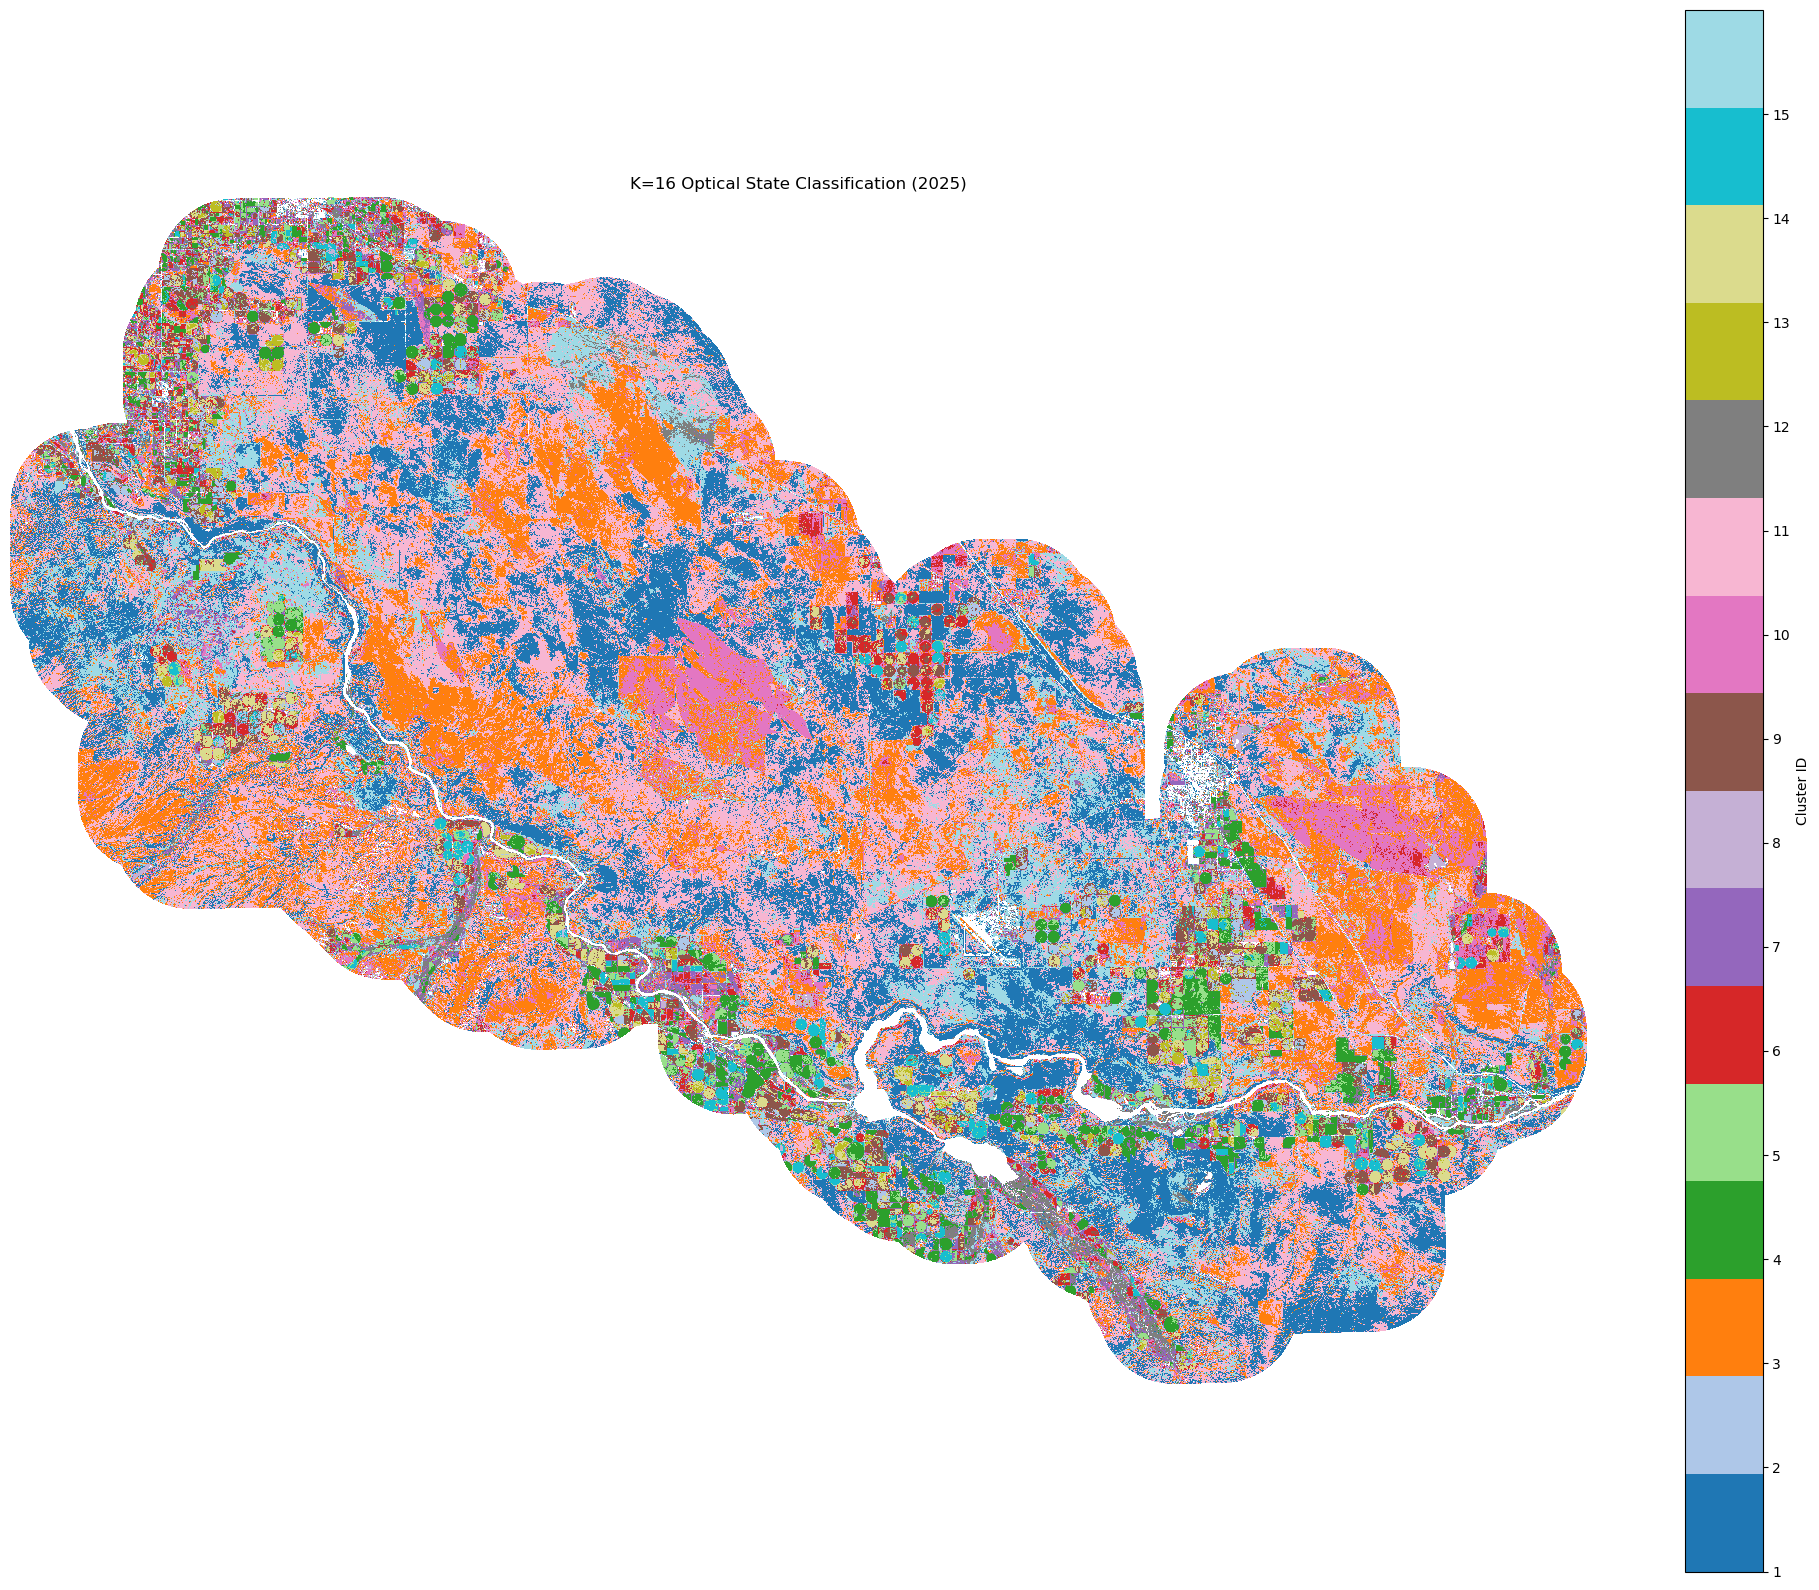

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path to raster
raster_path = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_k16_classified.tif"

# Read raster
with rasterio.open(raster_path) as src:
    data = src.read(1)
    nodata = src.nodata

# Mask nodata if present
if nodata is not None:
    data = np.where(data == nodata, np.nan, data)

# Plot
plt.figure(figsize=(20, 16))

# Use a discrete colormap with enough colors
cmap = plt.get_cmap('tab20', 16)  # 16 discrete classes

im = plt.imshow(data, cmap=cmap, interpolation='nearest')

plt.title("K=16 Optical State Classification (2025)")
plt.axis('off')

# Optional colorbar (class IDs)
cbar = plt.colorbar(im, ticks=range(16))
cbar.set_label("Cluster ID")

plt.tight_layout()
plt.show()

In [5]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import rasterio


# =============================================================================
# PATHS
# =============================================================================

# Source amp/phase raster used to derive the energy feature space
src_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_4th_amp_phase_masked.tif"
)

# Directory from the original energy/full50 subset workflow
cluster_v3_dir = Path(r"C:\NCA_DATA\Clustering\cluster_v3")

# Directory from the k=16 deep dive
k16_dir = Path(r"C:\NCA_DATA\cluster_v4_energy_k16_deepdive")

# Output 16-band centroid-distance raster
out_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_k16_centroid_distance.tif"
)


# =============================================================================
# SETTINGS
# =============================================================================

RAW_BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

# Explicit band map copied from the original subset-generation script.
# These are 1-based raster band numbers in the amp/phase raster.
FEATURE_MAP = {
    "B2":  {"BETA0": 1,  "AMP1": 2,  "AMP2": 4,  "AMP3": 6,  "AMP4": 8},
    "B3":  {"BETA0": 11, "AMP1": 12, "AMP2": 14, "AMP3": 16, "AMP4": 18},
    "B4":  {"BETA0": 21, "AMP1": 22, "AMP2": 24, "AMP3": 26, "AMP4": 28},
    "B5":  {"BETA0": 31, "AMP1": 32, "AMP2": 34, "AMP3": 36, "AMP4": 38},
    "B6":  {"BETA0": 41, "AMP1": 42, "AMP2": 44, "AMP3": 46, "AMP4": 48},
    "B7":  {"BETA0": 51, "AMP1": 52, "AMP2": 54, "AMP3": 56, "AMP4": 58},
    "B8":  {"BETA0": 61, "AMP1": 62, "AMP2": 64, "AMP3": 66, "AMP4": 68},
    "B8A": {"BETA0": 71, "AMP1": 72, "AMP2": 74, "AMP3": 76, "AMP4": 78},
    "B11": {"BETA0": 81, "AMP1": 82, "AMP2": 84, "AMP3": 86, "AMP4": 88},
    "B12": {"BETA0": 91, "AMP1": 92, "AMP2": 94, "AMP3": 96, "AMP4": 98},
}

OUT_DTYPE = "float32"
OUT_NODATA = -32768.0
OUT_COMPRESS = "lzw"


# =============================================================================
# HELPERS
# =============================================================================

def validate_feature_map(feature_map: dict[str, dict[str, int]]) -> None:
    needed = ["BETA0", "AMP1", "AMP2", "AMP3", "AMP4"]
    for band in RAW_BANDS:
        if band not in feature_map:
            raise RuntimeError(f"Missing band {band} in FEATURE_MAP")
        for comp in needed:
            if comp not in feature_map[band]:
                raise RuntimeError(f"Missing {comp} for {band}")


def get_selected_band_indices(feature_map: dict[str, dict[str, int]]) -> list[int]:
    """
    Returns sorted unique 1-based raster band numbers needed to rebuild
    the energy feature space.
    """
    selected = []
    for band in RAW_BANDS:
        selected.extend([
            feature_map[band]["BETA0"],
            feature_map[band]["AMP1"],
            feature_map[band]["AMP2"],
            feature_map[band]["AMP3"],
            feature_map[band]["AMP4"],
        ])
    return sorted(set(selected))


def build_selected_band_lookup(
    feature_map: dict[str, dict[str, int]],
    selected_indices: list[int]
) -> dict[str, dict[str, int]]:
    """
    Maps original 1-based raster band numbers to 0-based positions within the
    block array returned by src.read(indexes=selected_indices, ...).
    """
    pos_map = {idx: pos for pos, idx in enumerate(selected_indices)}
    return {
        band: {comp: pos_map[idx] for comp, idx in feature_map[band].items()}
        for band in RAW_BANDS
    }


def get_valid_mask(arr: np.ma.MaskedArray, src: rasterio.io.DatasetReader) -> np.ndarray:
    """
    Valid where:
    - no band is masked
    - all values are finite
    - no band equals dataset nodata (if nodata is defined)
    """
    valid = (~np.any(arr.mask, axis=0)) & np.all(np.isfinite(arr.data), axis=0)

    nodata = src.nodata
    if nodata is not None:
        valid &= ~np.any(arr.data == nodata, axis=0)

    return valid


def extract_energy_features_from_block(
    block: np.ndarray,
    lookup: dict[str, dict[str, int]]
) -> np.ndarray:
    """
    Reconstructs the 20-feature energy representation used in training:
    for each raw band: [BETA0, ENERGY], where
    ENERGY = sqrt(AMP1^2 + AMP2^2 + AMP3^2 + AMP4^2)

    Input block shape: (n_selected_bands, rows, cols)
    Output shape: (rows*cols, 20)
    """
    energy_cols = []

    for band in RAW_BANDS:
        beta0 = block[lookup[band]["BETA0"]].reshape(-1)
        a1 = block[lookup[band]["AMP1"]].reshape(-1)
        a2 = block[lookup[band]["AMP2"]].reshape(-1)
        a3 = block[lookup[band]["AMP3"]].reshape(-1)
        a4 = block[lookup[band]["AMP4"]].reshape(-1)

        energy = np.sqrt(a1**2 + a2**2 + a3**2 + a4**2)

        energy_cols.extend([beta0, energy])

    return np.column_stack(energy_cols).astype(np.float32)


def load_selected_run(selected_run_path: Path) -> int:
    txt = selected_run_path.read_text(encoding="utf-8").strip()
    if not txt.startswith("selected_run="):
        raise RuntimeError(f"Unexpected selected-run file contents: {txt}")
    return int(txt.split("=")[1])


def compute_centroid_distances(Xz: np.ndarray, centers: np.ndarray) -> np.ndarray:
    """
    Euclidean distance from each standardized observation to each centroid.

    Xz shape: (n, p)
    centers shape: (k, p)
    returns: (n, k)
    """
    x2 = np.sum(Xz ** 2, axis=1, keepdims=True)      # (n, 1)
    c2 = np.sum(centers ** 2, axis=1)[None, :]       # (1, k)
    d2 = x2 + c2 - 2.0 * (Xz @ centers.T)
    d2 = np.maximum(d2, 0.0)
    return np.sqrt(d2).astype(np.float32)


# =============================================================================
# MAIN
# =============================================================================

def main() -> None:
    validate_feature_map(FEATURE_MAP)

    # -------------------------------------------------------------------------
    # Load training artifacts
    # -------------------------------------------------------------------------
    p99_path = cluster_v3_dir / "energy_p99_thresholds.npy"
    scaler_path = k16_dir / "energy_k16_scaler_stats.npz"
    bundle_path = k16_dir / "energy_k16_bundle.npz"
    selected_run_path = k16_dir / "energy_k16_selected_run.txt"

    print("Loading training artifacts...")
    p99 = np.load(p99_path).astype(np.float32)
    scaler_stats = np.load(scaler_path)
    bundle = np.load(bundle_path)

    mean_ = scaler_stats["mean_"].astype(np.float32)
    scale_ = scaler_stats["scale_"].astype(np.float32)
    selected_run = load_selected_run(selected_run_path)

    center_key = f"centers_run{selected_run}"
    if center_key not in bundle:
        raise RuntimeError(f"Could not find {center_key} in {bundle_path}")

    centers = bundle[center_key].astype(np.float32)

    n_features = len(RAW_BANDS) * 2
    if p99.shape[0] != n_features:
        raise RuntimeError(f"Expected {n_features} p99 thresholds, found {p99.shape[0]}")
    if mean_.shape[0] != n_features:
        raise RuntimeError(f"Expected {n_features} scaler means, found {mean_.shape[0]}")
    if scale_.shape[0] != n_features:
        raise RuntimeError(f"Expected {n_features} scaler scales, found {scale_.shape[0]}")
    if centers.shape[1] != n_features:
        raise RuntimeError(
            f"Expected centroid feature dimension {n_features}, found {centers.shape[1]}"
        )

    k = centers.shape[0]

    print(f"Selected run: {selected_run}")
    print(f"Centroids: {centers.shape}")
    print(f"Expected feature count: {n_features}")
    print(f"k = {k}")

    # -------------------------------------------------------------------------
    # Build band lookup for source raster reads
    # -------------------------------------------------------------------------
    selected_indices = get_selected_band_indices(FEATURE_MAP)
    lookup = build_selected_band_lookup(FEATURE_MAP, selected_indices)

    print(f"Reading {len(selected_indices)} source bands from amp/phase raster.")
    print(f"Output raster: {out_raster}")

    # -------------------------------------------------------------------------
    # Process raster in blocks
    # -------------------------------------------------------------------------
    total_pixels = 0
    total_valid = 0

    with rasterio.open(src_raster) as src:
        profile = src.profile.copy()

        max_band_needed = max(selected_indices)
        if src.count < max_band_needed:
            raise RuntimeError(
                f"Source raster has {src.count} bands but classifier needs band {max_band_needed}"
            )

        profile.update(
            count=k,
            dtype=OUT_DTYPE,
            nodata=OUT_NODATA,
            compress=OUT_COMPRESS
        )

        with rasterio.open(out_raster, "w", **profile) as dst:
            for block_i, (_, window) in enumerate(src.block_windows(1), start=1):
                arr = src.read(indexes=selected_indices, window=window, masked=True)
                valid = get_valid_mask(arr, src)

                rows, cols = valid.shape
                n_pix = rows * cols
                n_valid = int(valid.sum())

                total_pixels += n_pix
                total_valid += n_valid

                out = np.full((k, rows, cols), OUT_NODATA, dtype=np.float32)

                if n_valid > 0:
                    block = arr.data.astype(np.float32)

                    # Rebuild 20-feature energy space exactly as in training workflow
                    Xe = extract_energy_features_from_block(block, lookup)  # (rows*cols, 20)

                    flat_valid = valid.reshape(-1)
                    Xv = Xe[flat_valid]

                    # Apply saved p99 clipping from training
                    Xv = np.minimum(Xv, p99)

                    # Apply saved scaler from training
                    Xz = (Xv - mean_) / scale_
                    Xz = np.where(np.isfinite(Xz), Xz, 0.0).astype(np.float32)

                    # Distances to all centroids
                    d = compute_centroid_distances(Xz, centers)  # (n_valid, k)

                    # Write back into output block, one band per centroid
                    out_flat = out.reshape(k, -1)
                    out_flat[:, flat_valid] = d.T
                    out = out_flat.reshape(k, rows, cols)

                dst.write(out, window=window)

                if block_i % 100 == 0:
                    print(
                        f"Processed {block_i} blocks | "
                        f"valid pixels so far: {total_valid:,} / {total_pixels:,}"
                    )

    print("\nDone.")
    print(f"Wrote: {out_raster}")
    print(f"Total pixels: {total_pixels:,}")
    print(f"Valid pixels written: {total_valid:,}")
    print(f"Invalid/nodata pixels: {total_pixels - total_valid:,}")
    print("\nBand mapping:")
    for cid in range(1, k + 1):
        print(f"  band {cid:2d} = distance to centroid/class {cid:2d}")


if __name__ == "__main__":
    main()

Loading training artifacts...
Selected run: 5
Centroids: (16, 20)
Expected feature count: 20
k = 16
Reading 50 source bands from amp/phase raster.
Output raster: C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_k16_centroid_distance.tif
Processed 100 blocks | valid pixels so far: 1,784,134 / 6,522,368
Processed 200 blocks | valid pixels so far: 3,777,245 / 13,044,736
Processed 300 blocks | valid pixels so far: 6,914,086 / 19,551,488
Processed 400 blocks | valid pixels so far: 10,616,668 / 26,073,856
Processed 500 blocks | valid pixels so far: 14,833,261 / 32,580,608
Processed 600 blocks | valid pixels so far: 20,248,467 / 39,102,976
Processed 700 blocks | valid pixels so far: 25,445,381 / 45,609,728
Processed 800 blocks | valid pixels so far: 30,662,992 / 52,132,096
Processed 900 blocks | valid pixels so far: 35,482,568 / 58,654,464
Processed 1000 blocks | valid pixels so far: 38,331,230 / 65,161,216
Processed 1100 blocks | valid pixels so far: 41,408,785 / 71,683,584
Processed 

In [6]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import rasterio


# =============================================================================
# PATHS
# =============================================================================

# 16-band centroid-distance raster
src_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_k16_centroid_distance.tif"
)

# Output directory
out_dir = Path(r"C:\NCA_DATA\S2_Harmonics_vrt")
out_dir.mkdir(parents=True, exist_ok=True)

# Outputs
nearest_dist_raster = out_dir / "S2SR_Harmonics_2025_energy_k16_nearest_distance.tif"
second_dist_raster  = out_dir / "S2SR_Harmonics_2025_energy_k16_second_distance.tif"
margin_raster       = out_dir / "S2SR_Harmonics_2025_energy_k16_margin_d2_minus_d1.tif"
nearest_class_raster = out_dir / "S2SR_Harmonics_2025_energy_k16_nearest_class.tif"
runnerup_class_raster = out_dir / "S2SR_Harmonics_2025_energy_k16_runnerup_class.tif"


# =============================================================================
# SETTINGS
# =============================================================================

DIST_DTYPE = "float32"
CLASS_DTYPE = "uint8"
OUT_NODATA_FLOAT = -32768.0
OUT_NODATA_CLASS = 0
OUT_COMPRESS = "lzw"


# =============================================================================
# HELPERS
# =============================================================================

def get_valid_mask(
    arr: np.ma.MaskedArray,
    nodata: float | int | None
) -> np.ndarray:
    """
    Valid where:
    - no band is masked
    - all values are finite
    - no band equals nodata (if nodata is defined)
    """
    valid = (~np.any(arr.mask, axis=0)) & np.all(np.isfinite(arr.data), axis=0)

    if nodata is not None:
        valid &= ~np.any(arr.data == nodata, axis=0)

    return valid


# =============================================================================
# MAIN
# =============================================================================

def main() -> None:
    total_pixels = 0
    total_valid = 0

    with rasterio.open(src_raster) as src:
        profile = src.profile.copy()

        if src.count < 2:
            raise RuntimeError("Need at least 2 centroid-distance bands to compute d1, d2, and margin.")

        k = src.count
        print(f"Input raster: {src_raster}")
        print(f"Centroid bands: {k}")

        dist_profile = profile.copy()
        dist_profile.update(
            count=1,
            dtype=DIST_DTYPE,
            nodata=OUT_NODATA_FLOAT,
            compress=OUT_COMPRESS
        )

        class_profile = profile.copy()
        class_profile.update(
            count=1,
            dtype=CLASS_DTYPE,
            nodata=OUT_NODATA_CLASS,
            compress=OUT_COMPRESS
        )

        with rasterio.open(nearest_dist_raster, "w", **dist_profile) as dst_d1, \
             rasterio.open(second_dist_raster, "w", **dist_profile) as dst_d2, \
             rasterio.open(margin_raster, "w", **dist_profile) as dst_margin, \
             rasterio.open(nearest_class_raster, "w", **class_profile) as dst_c1, \
             rasterio.open(runnerup_class_raster, "w", **class_profile) as dst_c2:

            for block_i, (_, window) in enumerate(src.block_windows(1), start=1):
                arr = src.read(window=window, masked=True)  # shape: (k, rows, cols)
                valid = get_valid_mask(arr, src.nodata)

                rows, cols = valid.shape
                n_pix = rows * cols
                n_valid = int(valid.sum())

                total_pixels += n_pix
                total_valid += n_valid

                out_d1 = np.full((rows, cols), OUT_NODATA_FLOAT, dtype=np.float32)
                out_d2 = np.full((rows, cols), OUT_NODATA_FLOAT, dtype=np.float32)
                out_margin = np.full((rows, cols), OUT_NODATA_FLOAT, dtype=np.float32)
                out_c1 = np.full((rows, cols), OUT_NODATA_CLASS, dtype=np.uint8)
                out_c2 = np.full((rows, cols), OUT_NODATA_CLASS, dtype=np.uint8)

                if n_valid > 0:
                    block = arr.data.astype(np.float32).reshape(k, -1)   # (k, n_pix)
                    flat_valid = valid.reshape(-1)

                    D = block[:, flat_valid].T  # (n_valid, k)

                    # Sort distances per pixel
                    order = np.argsort(D, axis=1)
                    D_sorted = np.take_along_axis(D, order, axis=1)

                    d1 = D_sorted[:, 0]
                    d2 = D_sorted[:, 1]
                    margin = d2 - d1

                    # Convert centroid index (0-based) to class ID (1-based)
                    c1 = (order[:, 0] + 1).astype(np.uint8)
                    c2 = (order[:, 1] + 1).astype(np.uint8)

                    out_d1_flat = out_d1.reshape(-1)
                    out_d2_flat = out_d2.reshape(-1)
                    out_margin_flat = out_margin.reshape(-1)
                    out_c1_flat = out_c1.reshape(-1)
                    out_c2_flat = out_c2.reshape(-1)

                    out_d1_flat[flat_valid] = d1
                    out_d2_flat[flat_valid] = d2
                    out_margin_flat[flat_valid] = margin
                    out_c1_flat[flat_valid] = c1
                    out_c2_flat[flat_valid] = c2

                    out_d1 = out_d1_flat.reshape(rows, cols)
                    out_d2 = out_d2_flat.reshape(rows, cols)
                    out_margin = out_margin_flat.reshape(rows, cols)
                    out_c1 = out_c1_flat.reshape(rows, cols)
                    out_c2 = out_c2_flat.reshape(rows, cols)

                dst_d1.write(out_d1, 1, window=window)
                dst_d2.write(out_d2, 1, window=window)
                dst_margin.write(out_margin, 1, window=window)
                dst_c1.write(out_c1, 1, window=window)
                dst_c2.write(out_c2, 1, window=window)

                if block_i % 100 == 0:
                    print(
                        f"Processed {block_i} blocks | "
                        f"valid pixels so far: {total_valid:,} / {total_pixels:,}"
                    )

    print("\nDone.")
    print(f"Wrote: {nearest_dist_raster}")
    print(f"Wrote: {second_dist_raster}")
    print(f"Wrote: {margin_raster}")
    print(f"Wrote: {nearest_class_raster}")
    print(f"Wrote: {runnerup_class_raster}")
    print(f"Total pixels: {total_pixels:,}")
    print(f"Valid pixels processed: {total_valid:,}")
    print(f"Invalid/nodata pixels: {total_pixels - total_valid:,}")


if __name__ == "__main__":
    main()

Input raster: C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_k16_centroid_distance.tif
Centroid bands: 16
Processed 100 blocks | valid pixels so far: 1,784,134 / 6,522,368
Processed 200 blocks | valid pixels so far: 3,777,245 / 13,044,736
Processed 300 blocks | valid pixels so far: 6,914,086 / 19,551,488
Processed 400 blocks | valid pixels so far: 10,616,668 / 26,073,856
Processed 500 blocks | valid pixels so far: 14,833,261 / 32,580,608
Processed 600 blocks | valid pixels so far: 20,248,467 / 39,102,976
Processed 700 blocks | valid pixels so far: 25,445,381 / 45,609,728
Processed 800 blocks | valid pixels so far: 30,662,992 / 52,132,096
Processed 900 blocks | valid pixels so far: 35,482,568 / 58,654,464
Processed 1000 blocks | valid pixels so far: 38,331,230 / 65,161,216
Processed 1100 blocks | valid pixels so far: 41,408,785 / 71,683,584
Processed 1200 blocks | valid pixels so far: 42,990,106 / 78,190,336

Done.
Wrote: C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_

In [ ]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize

# ---------------------------------------------------------------------
# PATHS
# ---------------------------------------------------------------------
template_raster = Path(r"C:\NCA_DATA\templates\grid_template_10m_26911_uint8.tif")
mask_vector = Path(r"H:\NCA\2026_Sampling\mask\SampFrame_AgEx_NAD83.shp")
out_mask_raster = Path(r"C:\NCA_DATA\templates\SampFrame_AgEx_mask_10m_26911.tif")

# ---------------------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------------------
VALID_VALUE = 1
OUT_DTYPE = "uint8"
OUT_NODATA = 0
OUT_COMPRESS = "lzw"
ALL_TOUCHED = False  # keep conservative pixel assignment

# ---------------------------------------------------------------------
# LOAD TEMPLATE + VECTOR
# ---------------------------------------------------------------------
print("Reading template raster...")
with rasterio.open(template_raster) as src:
    template_profile = src.profile.copy()
    template_transform = src.transform
    template_crs = src.crs
    template_height = src.height
    template_width = src.width

print("Reading mask shapefile...")
gdf = gpd.read_file(mask_vector)

if gdf.empty:
    raise RuntimeError("Mask shapefile is empty.")

if gdf.crs != template_crs:
    print("Reprojecting shapefile to template CRS...")
    gdf = gdf.to_crs(template_crs)

# Drop empty / invalid geometries
gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notnull()].copy()

if gdf.empty:
    raise RuntimeError("No valid geometries remain after filtering.")

# ---------------------------------------------------------------------
# RASTERIZE
# ---------------------------------------------------------------------
print("Rasterizing mask onto template grid...")
shapes = ((geom, VALID_VALUE) for geom in gdf.geometry)

mask_arr = rasterize(
    shapes=shapes,
    out_shape=(template_height, template_width),
    transform=template_transform,
    fill=OUT_NODATA,
    all_touched=ALL_TOUCHED,
    dtype=OUT_DTYPE
)

# ---------------------------------------------------------------------
# WRITE OUTPUT
# ---------------------------------------------------------------------
out_profile = template_profile.copy()
out_profile.update(
    count=1,
    dtype=OUT_DTYPE,
    nodata=OUT_NODATA,
    compress=OUT_COMPRESS
)

with rasterio.open(out_mask_raster, "w", **out_profile) as dst:
    dst.write(mask_arr, 1)

# ---------------------------------------------------------------------
# REPORT
# ---------------------------------------------------------------------
valid_pixels = int(np.sum(mask_arr == VALID_VALUE))
invalid_pixels = int(np.sum(mask_arr == OUT_NODATA))
total_pixels = mask_arr.size

print("\nDone.")
print(f"Wrote: {out_mask_raster}")
print(f"Template shape: {template_height} rows x {template_width} cols")
print(f"Total pixels: {total_pixels:,}")
print(f"Valid mask pixels: {valid_pixels:,}")
print(f"Excluded pixels: {invalid_pixels:,}")
print(f"Percent valid: {100 * valid_pixels / total_pixels:.2f}%")

Reading template raster...
Reading mask shapefile...
Rasterizing mask onto template grid...

Done.
Wrote: C:\NCA_DATA\templates\SampFrame_AgEx_mask_10m_26911.tif
Template shape: 7857 rows x 10435 cols
Total pixels: 81,987,795
Valid mask pixels: 14,418,700
Excluded pixels: 67,569,095
Percent valid: 17.59%


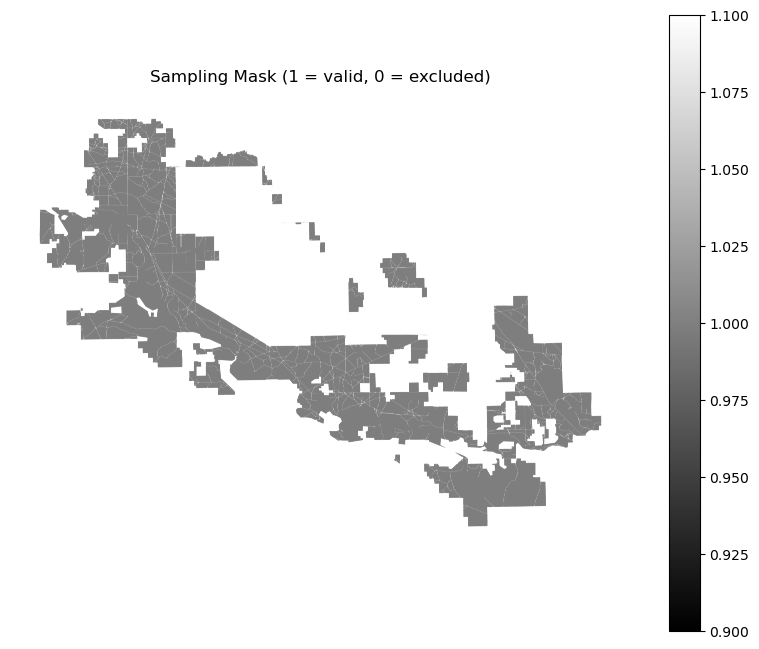

In [9]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

mask_path = r"C:\NCA_DATA\templates\SampFrame_AgEx_mask_10m_26911.tif"

with rasterio.open(mask_path) as src:
    mask = src.read(1)
    nodata = src.nodata

# Convert to display-friendly
mask_display = mask.astype(float)
mask_display[mask == nodata] = np.nan

# Plot
plt.figure(figsize=(10, 8))
plt.imshow(mask_display, cmap="gray")
plt.title("Sampling Mask (1 = valid, 0 = excluded)")
plt.colorbar()
plt.axis("off")
plt.show()

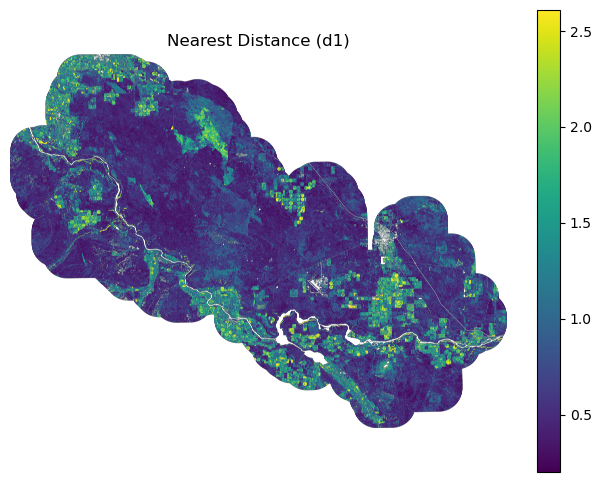

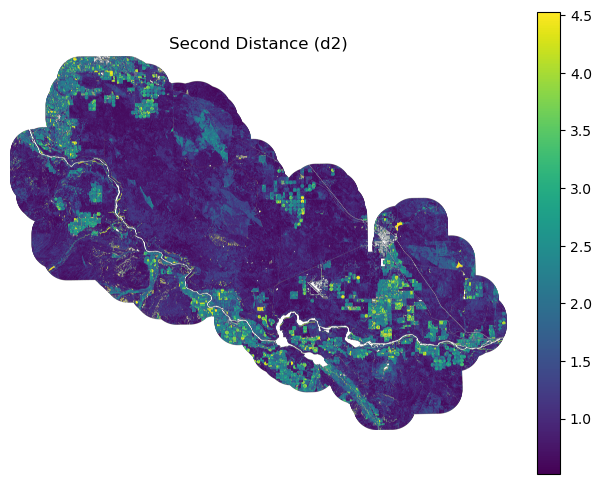

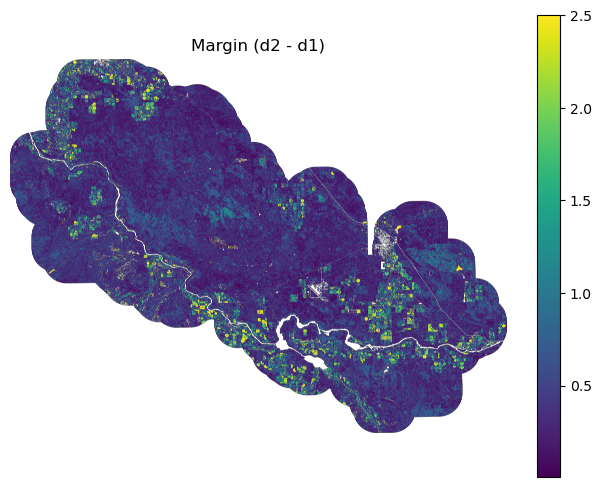

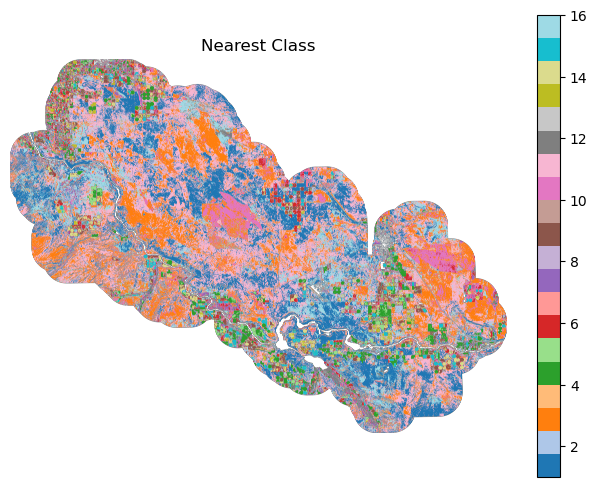

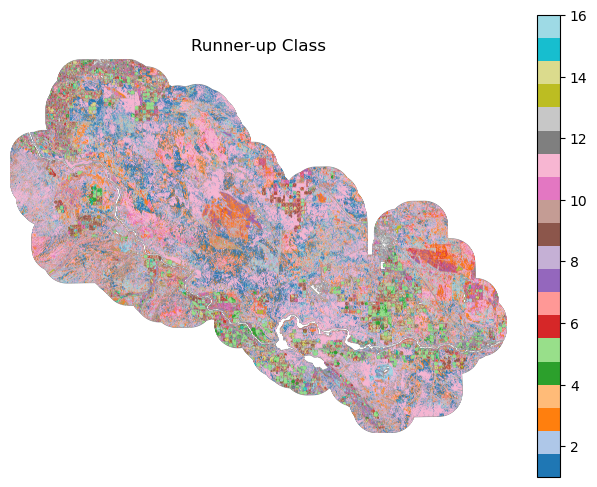

In [7]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Paths
base = r"C:\NCA_DATA\S2_Harmonics_vrt"

rasters = {
    "Nearest Distance": f"{base}\\S2SR_Harmonics_2025_energy_k16_nearest_distance.tif",
    "Second Distance": f"{base}\\S2SR_Harmonics_2025_energy_k16_second_distance.tif",
    "Margin (d2 - d1)": f"{base}\\S2SR_Harmonics_2025_energy_k16_margin_d2_minus_d1.tif",
    "Nearest Class": f"{base}\\S2SR_Harmonics_2025_energy_k16_nearest_class.tif",
    "Runner-up Class": f"{base}\\S2SR_Harmonics_2025_energy_k16_runnerup_class.tif",
}

def plot_raster(path, title, percentile_clip=None, cmap="viridis"):
    with rasterio.open(path) as src:
        arr = src.read(1)
        nodata = src.nodata

    # mask nodata
    arr = np.where(arr == nodata, np.nan, arr)

    # clip for visualization
    if percentile_clip:
        vmin, vmax = np.nanpercentile(arr, percentile_clip)
    else:
        vmin, vmax = np.nanmin(arr), np.nanmax(arr)

    plt.figure(figsize=(8, 6))
    plt.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.axis("off")
    plt.show()


# Plot each
plot_raster(rasters["Nearest Distance"], "Nearest Distance (d1)", (1, 99))
plot_raster(rasters["Second Distance"], "Second Distance (d2)", (1, 99))
plot_raster(rasters["Margin (d2 - d1)"], "Margin (d2 - d1)", (1, 99))

# Classes (no clipping)
plot_raster(rasters["Nearest Class"], "Nearest Class", None, cmap="tab20")
plot_raster(rasters["Runner-up Class"], "Runner-up Class", None, cmap="tab20")

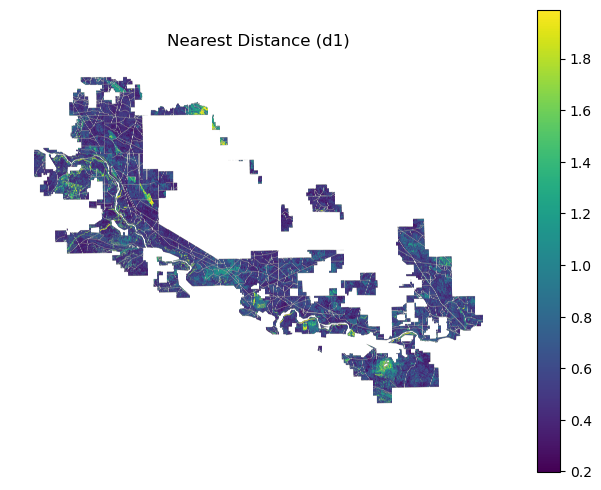

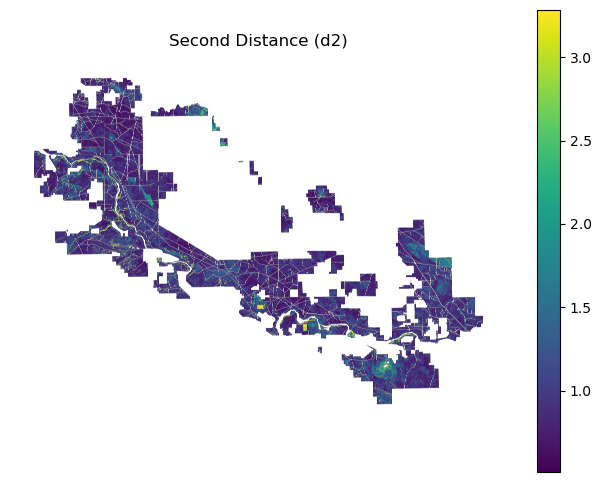

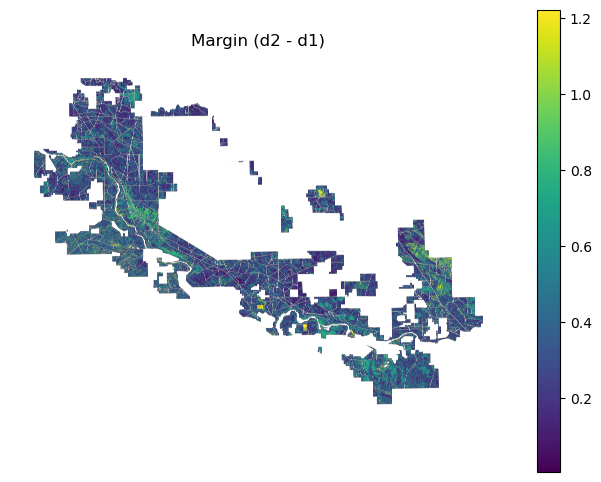

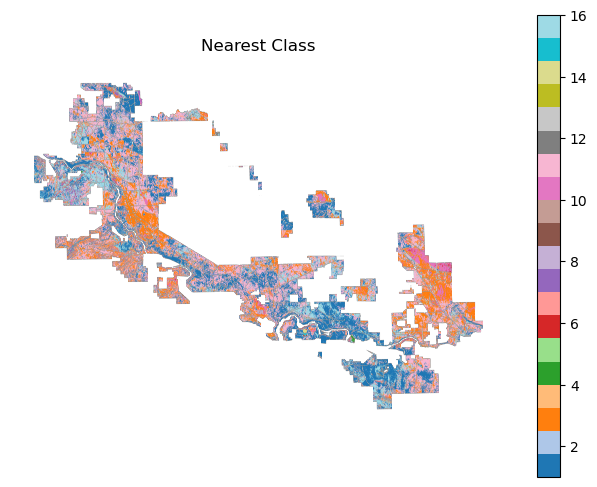

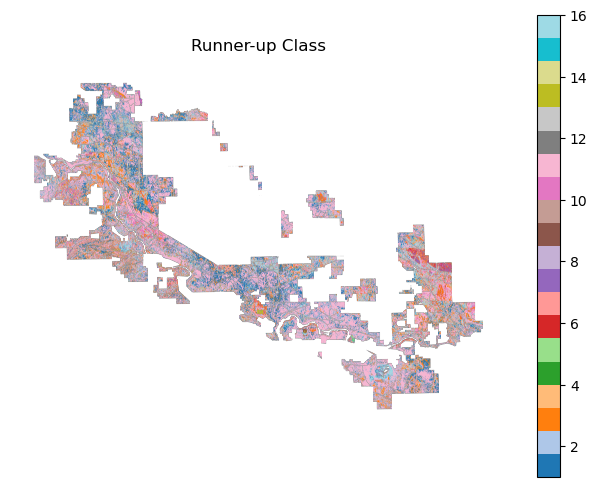

In [10]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Paths
base = r"C:\NCA_DATA\S2_Harmonics_vrt"
mask_path = r"C:\NCA_DATA\templates\SampFrame_AgEx_mask_10m_26911.tif"

rasters = {
    "Nearest Distance": f"{base}\\S2SR_Harmonics_2025_energy_k16_nearest_distance.tif",
    "Second Distance": f"{base}\\S2SR_Harmonics_2025_energy_k16_second_distance.tif",
    "Margin (d2 - d1)": f"{base}\\S2SR_Harmonics_2025_energy_k16_margin_d2_minus_d1.tif",
    "Nearest Class": f"{base}\\S2SR_Harmonics_2025_energy_k16_nearest_class.tif",
    "Runner-up Class": f"{base}\\S2SR_Harmonics_2025_energy_k16_runnerup_class.tif",
}

# Load mask once
with rasterio.open(mask_path) as msrc:
    mask = msrc.read(1)

def plot_raster(path, title, percentile_clip=None, cmap="viridis"):
    with rasterio.open(path) as src:
        arr = src.read(1)
        nodata = src.nodata

    # Convert to float for NaN handling
    arr = arr.astype(float)

    # Apply nodata mask
    if nodata is not None:
        arr[arr == nodata] = np.nan

    # Apply sampling mask (keep only where mask == 1)
    arr[mask != 1] = np.nan

    # Clip for visualization
    if percentile_clip:
        vmin, vmax = np.nanpercentile(arr, percentile_clip)
    else:
        vmin, vmax = np.nanmin(arr), np.nanmax(arr)

    plt.figure(figsize=(8, 6))
    plt.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.axis("off")
    plt.show()


# Plot each
plot_raster(rasters["Nearest Distance"], "Nearest Distance (d1)", (1, 99))
plot_raster(rasters["Second Distance"], "Second Distance (d2)", (1, 99))
plot_raster(rasters["Margin (d2 - d1)"], "Margin (d2 - d1)", (1, 99))

# Classes (no clipping)
plot_raster(rasters["Nearest Class"], "Nearest Class", None, cmap="tab20")
plot_raster(rasters["Runner-up Class"], "Runner-up Class", None, cmap="tab20")

Valid pixel count: 14,131,820

Summary Statistics:
Min:  0.0000
Max:  5.0346
Mean: 0.3800
Std:  0.3607

Percentiles:
  0% : 0.0000
  5% : 0.0290
 10% : 0.0587
 20% : 0.1202
 25% : 0.1521
 50% : 0.3261
 75% : 0.5399
 80% : 0.5928
 90% : 0.7227
 95% : 0.8017
100% : 5.0346


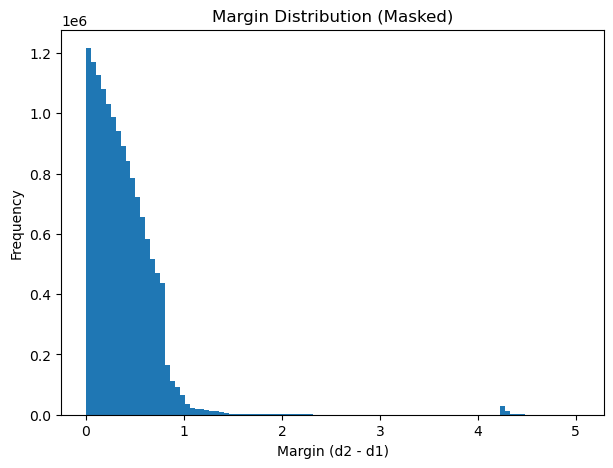

In [11]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Path to MASKED margin raster
margin_path = r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_k16_margin_d2_minus_d1.tif"
mask_path   = r"C:\NCA_DATA\templates\SampFrame_AgEx_mask_10m_26911.tif"

# Load data
with rasterio.open(margin_path) as src:
    margin = src.read(1)
    nodata = src.nodata

with rasterio.open(mask_path) as msrc:
    mask = msrc.read(1)

# Apply mask + nodata
margin = margin.astype(float)
if nodata is not None:
    margin[margin == nodata] = np.nan

margin[mask != 1] = np.nan

# Flatten valid values
vals = margin[np.isfinite(margin)]

print(f"Valid pixel count: {len(vals):,}")

# ---------------------------------------------------------------------
# SUMMARY STATS
# ---------------------------------------------------------------------
print("\nSummary Statistics:")
print(f"Min:  {np.min(vals):.4f}")
print(f"Max:  {np.max(vals):.4f}")
print(f"Mean: {np.mean(vals):.4f}")
print(f"Std:  {np.std(vals):.4f}")

# ---------------------------------------------------------------------
# PERCENTILES
# ---------------------------------------------------------------------
percentiles = [0, 5, 10, 20, 25, 50, 75, 80, 90, 95, 100]
pvals = np.percentile(vals, percentiles)

print("\nPercentiles:")
for p, v in zip(percentiles, pvals):
    print(f"{p:>3}% : {v:.4f}")

# ---------------------------------------------------------------------
# HISTOGRAM
# ---------------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.hist(vals, bins=100)
plt.title("Margin Distribution (Masked)")
plt.xlabel("Margin (d2 - d1)")
plt.ylabel("Frequency")
plt.show()

Reading margin raster...
Reading sampling mask raster...
Building margin strata masks...
Writing binary masks...
Extracting node centroids from connected patches...
[low] total labeled patches: 299,211
[low] patches >= 25 pixels: 19,033
[mid] total labeled patches: 56,966
[mid] patches >= 25 pixels: 3,323
[high] total labeled patches: 244,113
[high] patches >= 25 pixels: 15,504
19033 3323 15504

Done.
Low mask:   C:\NCA_DATA\nodes_margin\margin_low_mask.tif
Mid mask:   C:\NCA_DATA\nodes_margin\margin_mid_mask.tif
High mask:  C:\NCA_DATA\nodes_margin\margin_high_mask.tif

Low nodes:  C:\NCA_DATA\nodes_margin\margin_low_nodes.shp  | count = 19,033
Mid nodes:  C:\NCA_DATA\nodes_margin\margin_mid_nodes.shp  | count = 3,323
High nodes: C:\NCA_DATA\nodes_margin\margin_high_nodes.shp | count = 15,504

Pixel counts by stratum:
  Low:  3,534,077
  Mid:  8,479,573
  High: 2,826,595

Minimum patch size retained: 25 pixels


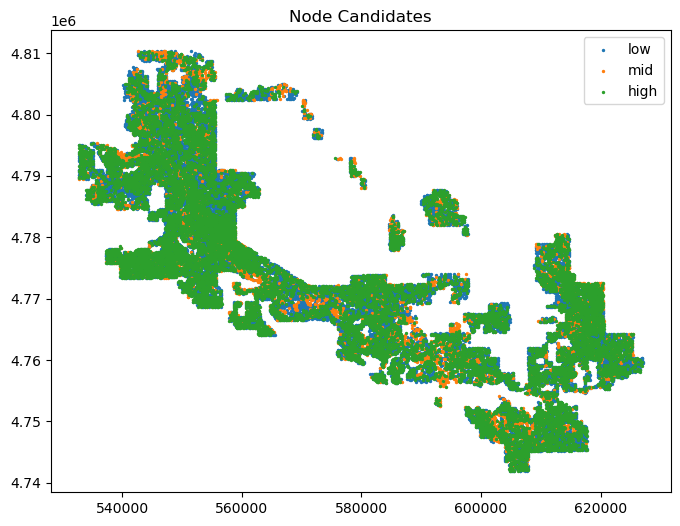

In [ ]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import rasterio
from rasterio.features import shapes
from rasterio.transform import xy
from scipy import ndimage
import geopandas as gpd
from shapely.geometry import shape, Point

# =============================================================================
# PATHS
# =============================================================================

margin_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_k16_margin_d2_minus_d1.tif"
)

sampling_mask_raster = Path(
    r"C:\NCA_DATA\templates\SampFrame_AgEx_mask_10m_26911.tif"
)

out_dir = Path(r"C:\NCA_DATA\nodes_margin")
out_dir.mkdir(parents=True, exist_ok=True)

low_mask_raster = out_dir / "margin_low_mask.tif"
mid_mask_raster = out_dir / "margin_mid_mask.tif"
high_mask_raster = out_dir / "margin_high_mask.tif"

low_nodes_shp = out_dir / "margin_low_nodes.shp"
mid_nodes_shp = out_dir / "margin_mid_nodes.shp"
high_nodes_shp = out_dir / "margin_high_nodes.shp"

# =============================================================================
# SETTINGS
# =============================================================================

MASK_KEEP_VALUE = 1
FLOAT_NODATA = -32768.0
BIN_NODATA = 0
BIN_DTYPE = "uint8"
COMPRESS = "lzw"

# Margin thresholds from your masked distribution
LOW_MAX = 0.1521

MID_MIN = 0.1202
MID_MAX = 0.5928

HIGH_MIN = 0.5399
HIGH_MAX = 0.8017

# Minimum connected patch size to keep as a node candidate
MIN_PATCH_PIXELS = 100

# Connectivity: 8-neighbor
STRUCTURE = ndimage.generate_binary_structure(2, 2)

# =============================================================================
# HELPERS
# =============================================================================

def write_binary_mask(arr: np.ndarray, profile: dict, out_path: Path) -> None:
    out_profile = profile.copy()
    out_profile.update(
        count=1,
        dtype=BIN_DTYPE,
        nodata=BIN_NODATA,
        compress=COMPRESS
    )
    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(arr.astype(np.uint8), 1)


def build_stratum_mask(
    margin: np.ndarray,
    valid_sampling: np.ndarray,
    lower: float | None,
    upper: float | None
) -> np.ndarray:
    """
    Build binary mask:
    1 = in stratum and in valid sampling space
    0 = otherwise
    """
    valid = np.isfinite(margin) & valid_sampling

    out = np.zeros(margin.shape, dtype=np.uint8)

    cond = valid.copy()
    if lower is not None:
        cond &= (margin >= lower)
    if upper is not None:
        cond &= (margin <= upper)

    out[cond] = 1
    return out


def extract_node_points_from_binary_mask(
    bin_mask: np.ndarray,
    transform,
    crs,
    min_patch_pixels: int,
    stratum_name: str
) -> gpd.GeoDataFrame:
    """
    Region-group a binary mask, remove small patches, and extract one centroid point per patch.
    Fast version using ndimage.center_of_mass.
    """
    labeled, nlab = ndimage.label(bin_mask == 1, structure=STRUCTURE)
    print(f"[{stratum_name}] total labeled patches: {nlab:,}")

    if nlab == 0:
        return gpd.GeoDataFrame(
            columns=["node_id", "stratum", "patch_pixels"],
            geometry=[],
            crs=crs
        )

    counts = np.bincount(labeled.ravel())
    keep_labels = np.where(counts >= min_patch_pixels)[0]
    keep_labels = keep_labels[keep_labels != 0]

    print(f"[{stratum_name}] patches >= {min_patch_pixels} pixels: {len(keep_labels):,}")

    if len(keep_labels) == 0:
        return gpd.GeoDataFrame(
            columns=["node_id", "stratum", "patch_pixels"],
            geometry=[],
            crs=crs
        )

    # Fast centroid computation
    centers = ndimage.center_of_mass(
        np.ones_like(labeled, dtype=np.uint8),
        labels=labeled,
        index=keep_labels
    )

    rows = []
    for node_id, (lab, center) in enumerate(zip(keep_labels, centers), start=1):
        r_mean, c_mean = center
        x, y = xy(transform, r_mean, c_mean)

        rows.append({
            "node_id": node_id,
            "stratum": stratum_name,
            "patch_pixels": int(counts[lab]),
            "geometry": Point(x, y)
        })

    return gpd.GeoDataFrame(rows, crs=crs)


# =============================================================================
# MAIN
# =============================================================================

print("Reading margin raster...")
with rasterio.open(margin_raster) as src:
    margin = src.read(1).astype(np.float32)
    margin_profile = src.profile.copy()
    margin_transform = src.transform
    margin_crs = src.crs
    margin_nodata = src.nodata

if margin_nodata is not None:
    margin[margin == margin_nodata] = np.nan

print("Reading sampling mask raster...")
with rasterio.open(sampling_mask_raster) as msrc:
    samp_mask = msrc.read(1)
    if (
        msrc.width != margin_profile["width"] or
        msrc.height != margin_profile["height"] or
        msrc.transform != margin_transform or
        msrc.crs != margin_crs
    ):
        raise RuntimeError("Sampling mask raster does not align with margin raster.")

valid_sampling = samp_mask == MASK_KEEP_VALUE

print("Building margin strata masks...")
low_mask = build_stratum_mask(margin, valid_sampling, lower=None, upper=LOW_MAX)
mid_mask = build_stratum_mask(margin, valid_sampling, lower=MID_MIN, upper=MID_MAX)
high_mask = build_stratum_mask(margin, valid_sampling, lower=HIGH_MIN, upper=HIGH_MAX)

print("Writing binary masks...")
write_binary_mask(low_mask, margin_profile, low_mask_raster)
write_binary_mask(mid_mask, margin_profile, mid_mask_raster)
write_binary_mask(high_mask, margin_profile, high_mask_raster)

print("Extracting node centroids from connected patches...")
gdf_low = extract_node_points_from_binary_mask(
    low_mask, margin_transform, margin_crs, MIN_PATCH_PIXELS, "low"
)
gdf_mid = extract_node_points_from_binary_mask(
    mid_mask, margin_transform, margin_crs, MIN_PATCH_PIXELS, "mid"
)
gdf_high = extract_node_points_from_binary_mask(
    high_mask, margin_transform, margin_crs, MIN_PATCH_PIXELS, "high"
)

#print("Writing node shapefiles...")
#gdf_low.to_file(low_nodes_shp)
#gdf_mid.to_file(mid_nodes_shp)
#gdf_high.to_file(high_nodes_shp)
print(len(gdf_low), len(gdf_mid), len(gdf_high))
# =============================================================================
# REPORT
# =============================================================================

def count_pixels(arr: np.ndarray) -> int:
    return int(np.sum(arr == 1))

print("\nDone.")
print(f"Low mask:   {low_mask_raster}")
print(f"Mid mask:   {mid_mask_raster}")
print(f"High mask:  {high_mask_raster}")

print(f"\nLow nodes:  {low_nodes_shp}  | count = {len(gdf_low):,}")
print(f"Mid nodes:  {mid_nodes_shp}  | count = {len(gdf_mid):,}")
print(f"High nodes: {high_nodes_shp} | count = {len(gdf_high):,}")

print("\nPixel counts by stratum:")
print(f"  Low:  {count_pixels(low_mask):,}")
print(f"  Mid:  {count_pixels(mid_mask):,}")
print(f"  High: {count_pixels(high_mask):,}")

print(f"\nMinimum patch size retained: {MIN_PATCH_PIXELS} pixels")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(gdf_low.geometry.x, gdf_low.geometry.y, s=2, label="low")
plt.scatter(gdf_mid.geometry.x, gdf_mid.geometry.y, s=2, label="mid")
plt.scatter(gdf_high.geometry.x, gdf_high.geometry.y, s=2, label="high")
plt.legend()
plt.title("Node Candidates")
plt.show()

Reading margin raster...
Reading sampling mask raster...
Building margin strata masks...
Writing binary masks...
Extracting node centroids from connected patches...
[low] total labeled patches: 299,211
[low] patches >= 250 pixels: 1,647
[mid] total labeled patches: 56,966
[mid] patches >= 250 pixels: 785
[high] total labeled patches: 244,113
[high] patches >= 250 pixels: 1,046

Raw node counts:
  low:  1,647
  mid:  785
  high: 1,046

Applying global thinning at 2000 m...

Thinned node counts:
stratum
high     10
low     248
mid      35
Name: count, dtype: int64

Writing thinned nodes...

Done.
Low mask:   C:\NCA_DATA\nodes_margin\margin_low_mask.tif
Mid mask:   C:\NCA_DATA\nodes_margin\margin_mid_mask.tif
High mask:  C:\NCA_DATA\nodes_margin\margin_high_mask.tif

Thinned nodes: C:\NCA_DATA\nodes_margin\margin_nodes_thinned_1p5km.shp | count = 293

Pixel counts by stratum:
  Low:  3,534,077
  Mid:  8,479,573


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_8356\4193556632.py:261: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_thinned.to_file(all_nodes_shp)
c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'patch_pixels' to 'patch_pixe'
  ogr_write(


  High: 2,826,595

Minimum patch size retained: 250 pixels
Minimum node spacing: 2000 m


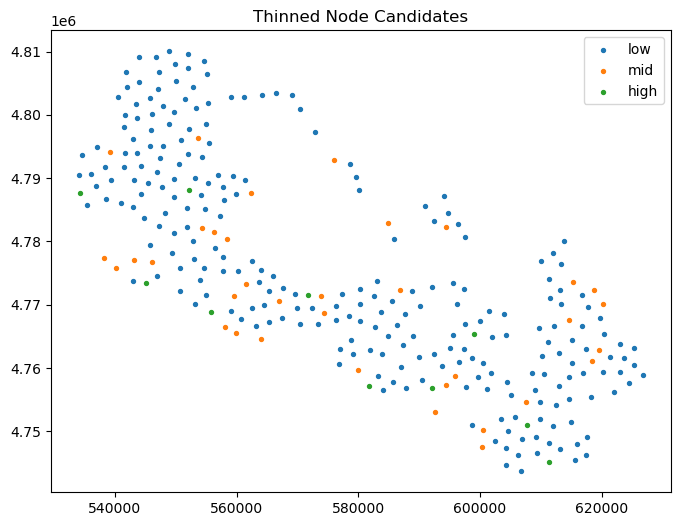

In [16]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import rasterio
from rasterio.transform import xy
from scipy import ndimage
from scipy.spatial import cKDTree
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# =============================================================================
# PATHS
# =============================================================================

margin_raster = Path(
    r"C:\NCA_DATA\S2_Harmonics_vrt\S2SR_Harmonics_2025_energy_k16_margin_d2_minus_d1.tif"
)

sampling_mask_raster = Path(
    r"C:\NCA_DATA\templates\SampFrame_AgEx_mask_10m_26911.tif"
)

out_dir = Path(r"C:\NCA_DATA\nodes_margin")
out_dir.mkdir(parents=True, exist_ok=True)

low_mask_raster = out_dir / "margin_low_mask.tif"
mid_mask_raster = out_dir / "margin_mid_mask.tif"
high_mask_raster = out_dir / "margin_high_mask.tif"

all_nodes_shp = out_dir / "margin_nodes_thinned_1p5km.shp"

# =============================================================================
# SETTINGS
# =============================================================================

MASK_KEEP_VALUE = 1
BIN_NODATA = 0
BIN_DTYPE = "uint8"
COMPRESS = "lzw"

# Margin thresholds from masked distribution
LOW_MAX = 0.1521

MID_MIN = 0.1202
MID_MAX = 0.5928

HIGH_MIN = 0.5399
HIGH_MAX = 0.8017

# Increase this a lot; 25 was far too permissive
MIN_PATCH_PIXELS = 250

# Minimum node spacing in meters
MIN_NODE_SPACING_M = 2000.0

# Connectivity: 8-neighbor
STRUCTURE = ndimage.generate_binary_structure(2, 2)

# Priority for thinning
STRATUM_PRIORITY = {"low": 1, "mid": 2, "high": 3}

# =============================================================================
# HELPERS
# =============================================================================

def write_binary_mask(arr: np.ndarray, profile: dict, out_path: Path) -> None:
    out_profile = profile.copy()
    out_profile.update(
        count=1,
        dtype=BIN_DTYPE,
        nodata=BIN_NODATA,
        compress=COMPRESS
    )
    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(arr.astype(np.uint8), 1)


def build_stratum_mask(
    margin: np.ndarray,
    valid_sampling: np.ndarray,
    lower: float | None,
    upper: float | None
) -> np.ndarray:
    valid = np.isfinite(margin) & valid_sampling
    out = np.zeros(margin.shape, dtype=np.uint8)

    cond = valid.copy()
    if lower is not None:
        cond &= (margin >= lower)
    if upper is not None:
        cond &= (margin <= upper)

    out[cond] = 1
    return out


def extract_node_points_from_binary_mask(
    bin_mask: np.ndarray,
    transform,
    crs,
    min_patch_pixels: int,
    stratum_name: str
) -> gpd.GeoDataFrame:
    """
    Region-group a binary mask, remove small patches, and extract one centroid point per patch.
    Fast version using ndimage.center_of_mass.
    """
    labeled, nlab = ndimage.label(bin_mask == 1, structure=STRUCTURE)
    print(f"[{stratum_name}] total labeled patches: {nlab:,}")

    if nlab == 0:
        return gpd.GeoDataFrame(
            columns=["node_id", "stratum", "patch_pixels", "priority"],
            geometry=[],
            crs=crs
        )

    counts = np.bincount(labeled.ravel())
    keep_labels = np.where(counts >= min_patch_pixels)[0]
    keep_labels = keep_labels[keep_labels != 0]

    print(f"[{stratum_name}] patches >= {min_patch_pixels} pixels: {len(keep_labels):,}")

    if len(keep_labels) == 0:
        return gpd.GeoDataFrame(
            columns=["node_id", "stratum", "patch_pixels", "priority"],
            geometry=[],
            crs=crs
        )

    centers = ndimage.center_of_mass(
        np.ones_like(labeled, dtype=np.uint8),
        labels=labeled,
        index=keep_labels
    )

    rows = []
    for node_id, (lab, center) in enumerate(zip(keep_labels, centers), start=1):
        r_mean, c_mean = center
        x, y = xy(transform, r_mean, c_mean)

        rows.append({
            "node_id": node_id,
            "stratum": stratum_name,
            "patch_pixels": int(counts[lab]),
            "priority": STRATUM_PRIORITY[stratum_name],
            "geometry": Point(x, y)
        })

    return gpd.GeoDataFrame(rows, crs=crs)


def thin_nodes_global(
    gdf: gpd.GeoDataFrame,
    min_spacing_m: float
) -> gpd.GeoDataFrame:
    """
    Global thinning across all strata.
    Priority order:
      1. lower 'priority' value first (low -> mid -> high)
      2. larger patch size first within stratum
    """
    if gdf.empty:
        return gdf.copy()

    work = gdf.copy()
    work = work.sort_values(
        by=["priority", "patch_pixels"],
        ascending=[True, False]
    ).reset_index(drop=True)

    coords = np.column_stack([work.geometry.x.values, work.geometry.y.values])

    keep = np.ones(len(work), dtype=bool)
    tree = cKDTree(coords)

    for i in range(len(work)):
        if not keep[i]:
            continue
        neighbors = tree.query_ball_point(coords[i], r=min_spacing_m)
        for j in neighbors:
            if j == i:
                continue
            keep[j] = False

    thinned = work.loc[keep].copy().reset_index(drop=True)
    thinned["thin_id"] = np.arange(1, len(thinned) + 1)

    return thinned


# =============================================================================
# MAIN
# =============================================================================

print("Reading margin raster...")
with rasterio.open(margin_raster) as src:
    margin = src.read(1).astype(np.float32)
    margin_profile = src.profile.copy()
    margin_transform = src.transform
    margin_crs = src.crs
    margin_nodata = src.nodata

if margin_nodata is not None:
    margin[margin == margin_nodata] = np.nan

print("Reading sampling mask raster...")
with rasterio.open(sampling_mask_raster) as msrc:
    samp_mask = msrc.read(1)
    if (
        msrc.width != margin_profile["width"] or
        msrc.height != margin_profile["height"] or
        msrc.transform != margin_transform or
        msrc.crs != margin_crs
    ):
        raise RuntimeError("Sampling mask raster does not align with margin raster.")

valid_sampling = samp_mask == MASK_KEEP_VALUE

print("Building margin strata masks...")
low_mask = build_stratum_mask(margin, valid_sampling, lower=None, upper=LOW_MAX)
mid_mask = build_stratum_mask(margin, valid_sampling, lower=MID_MIN, upper=MID_MAX)
high_mask = build_stratum_mask(margin, valid_sampling, lower=HIGH_MIN, upper=HIGH_MAX)

print("Writing binary masks...")
write_binary_mask(low_mask, margin_profile, low_mask_raster)
write_binary_mask(mid_mask, margin_profile, mid_mask_raster)
write_binary_mask(high_mask, margin_profile, high_mask_raster)

print("Extracting node centroids from connected patches...")
gdf_low = extract_node_points_from_binary_mask(
    low_mask, margin_transform, margin_crs, MIN_PATCH_PIXELS, "low"
)
gdf_mid = extract_node_points_from_binary_mask(
    mid_mask, margin_transform, margin_crs, MIN_PATCH_PIXELS, "mid"
)
gdf_high = extract_node_points_from_binary_mask(
    high_mask, margin_transform, margin_crs, MIN_PATCH_PIXELS, "high"
)

print("\nRaw node counts:")
print(f"  low:  {len(gdf_low):,}")
print(f"  mid:  {len(gdf_mid):,}")
print(f"  high: {len(gdf_high):,}")

gdf_all = gpd.GeoDataFrame(
    pd.concat([gdf_low, gdf_mid, gdf_high], ignore_index=True),
    crs=margin_crs
)

print(f"\nApplying global thinning at {MIN_NODE_SPACING_M:.0f} m...")
gdf_thinned = thin_nodes_global(gdf_all, MIN_NODE_SPACING_M)

print("\nThinned node counts:")
print(gdf_thinned["stratum"].value_counts().sort_index())

print("\nWriting thinned nodes...")
gdf_thinned.to_file(all_nodes_shp)

# =============================================================================
# REPORT
# =============================================================================

def count_pixels(arr: np.ndarray) -> int:
    return int(np.sum(arr == 1))

print("\nDone.")
print(f"Low mask:   {low_mask_raster}")
print(f"Mid mask:   {mid_mask_raster}")
print(f"High mask:  {high_mask_raster}")
print(f"\nThinned nodes: {all_nodes_shp} | count = {len(gdf_thinned):,}")

print("\nPixel counts by stratum:")
print(f"  Low:  {count_pixels(low_mask):,}")
print(f"  Mid:  {count_pixels(mid_mask):,}")
print(f"  High: {count_pixels(high_mask):,}")

print(f"\nMinimum patch size retained: {MIN_PATCH_PIXELS} pixels")
print(f"Minimum node spacing: {MIN_NODE_SPACING_M:.0f} m")

# Quick plot
plt.figure(figsize=(8, 6))
for stratum, color in [("low", "tab:blue"), ("mid", "tab:orange"), ("high", "tab:green")]:
    sub = gdf_thinned[gdf_thinned["stratum"] == stratum]
    plt.scatter(sub.geometry.x, sub.geometry.y, s=8, label=stratum, c=color)

plt.legend()
plt.title("Thinned Node Candidates")
plt.show()


=== Buffer: 260 m ===
Nearest-class richness:
  min=2 | p25=4.0 | med=4.0 | mean=5.04 | p75=6.0 | max=16
Nearest + runner-up richness:
  min=2 | p25=4.0 | med=5.0 | mean=6.01 | p75=7.0 | max=16

=== Buffer: 510 m ===
Nearest-class richness:
  min=3 | p25=5.0 | med=6.0 | mean=7.22 | p75=10.0 | max=16
Nearest + runner-up richness:
  min=3 | p25=5.0 | med=7.0 | mean=8.21 | p75=12.0 | max=16

=== Buffer: 760 m ===
Nearest-class richness:
  min=3 | p25=5.0 | med=7.0 | mean=8.75 | p75=12.0 | max=16
Nearest + runner-up richness:
  min=4 | p25=6.0 | med=9.0 | mean=9.76 | p75=13.0 | max=16


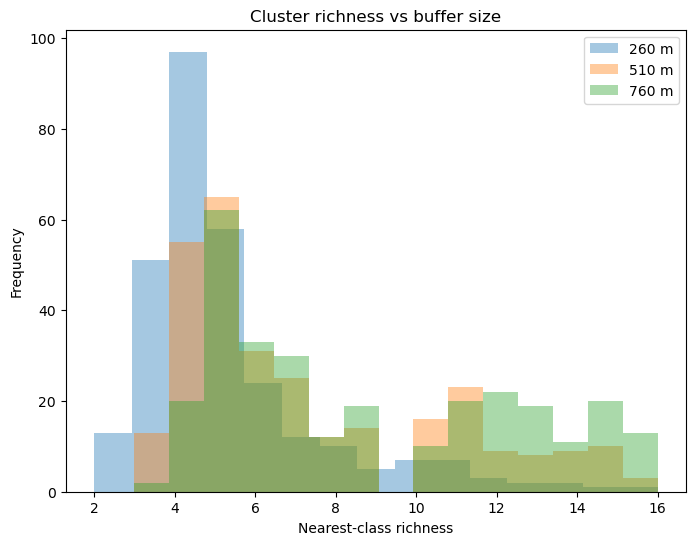

In [21]:
BUFFER_LIST = [260.0, 510.0, 760.0]

def summarize_for_buffer(buffer_m):
    nearest_counts = []
    combined_counts = []

    with rasterio.open(nearest_path) as src_near, rasterio.open(runnerup_path) as src_run:
        for geom in gdf.geometry:
            buf = geom.buffer(buffer_m)

            v1 = extract_masked_values(src_near, buf, samp_mask)
            v2 = extract_masked_values(src_run, buf, samp_mask)

            n = min(len(v1), len(v2))
            if n == 0:
                nearest_counts.append(0)
                combined_counts.append(0)
                continue

            v1 = v1[:n].astype(int)
            v2 = v2[:n].astype(int)

            nearest_counts.append(len(np.unique(v1)))
            combined_counts.append(len(np.unique(np.concatenate([v1, v2]))))

    nearest_counts = np.array(nearest_counts)
    combined_counts = np.array(combined_counts)

    return {
        "nearest": nearest_counts,
        "combined": combined_counts
    }

# -------------------------------------------------------------------
# RUN + PRINT
# -------------------------------------------------------------------

for b in BUFFER_LIST:
    res = summarize_for_buffer(b)

    n = res["nearest"]
    c = res["combined"]

    print(f"\n=== Buffer: {int(b)} m ===")

    print("Nearest-class richness:")
    print(f"  min={n.min()} | p25={np.percentile(n,25):.1f} | med={np.median(n):.1f} | mean={n.mean():.2f} | p75={np.percentile(n,75):.1f} | max={n.max()}")

    print("Nearest + runner-up richness:")
    print(f"  min={c.min()} | p25={np.percentile(c,25):.1f} | med={np.median(c):.1f} | mean={c.mean():.2f} | p75={np.percentile(c,75):.1f} | max={c.max()}")

    import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for b in BUFFER_LIST:
    res = summarize_for_buffer(b)
    plt.hist(res["nearest"], bins=15, alpha=0.4, label=f"{int(b)} m")

plt.xlabel("Nearest-class richness")
plt.ylabel("Frequency")
plt.legend()
plt.title("Cluster richness vs buffer size")
plt.show()